In [ ]:
from pathlib import Path

import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

In [ ]:

_here = Path.cwd()
REPO_DIR = next((p for p in [_here, *_here.parents]
                 if (p / '.gitattributes').exists() or (p / '.git').exists()), None)
if REPO_DIR is None:
    raise FileNotFoundError("Open this notebook from inside the SM_Dissertation repository folder.")

FILE_PATH = _here / "Input Data" / "SHS_Viability_Model_v5_1.xlsm"
OUT_DIR = REPO_DIR / "Figures"
OUT_DIR.mkdir(exist_ok=True)

if not FILE_PATH.exists():
    raise FileNotFoundError(f"{FILE_PATH.name} not found in {FILE_PATH.parent} — put the workbook in the Input Data folder.")

In [ ]:

COLOR_UTILITY = "#2166AC"
COLOR_OPERATOR = "#D6604D"
COLOR_KENYA = "#D6604D"
COLOR_ZAMBIA = "#2166AC"
COLOR_PAYGO = "#7F7F7F"
COLOR_GRID = "#D9D9D9"
COLOR_ZERO = "#999999"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

def money_fmt(x, pos):
    return f"${x/1e6:,.0f}M"

def pct_fmt(x, pos):
    return f"{x*100:.0f}%"

def clean_axis(ax, y_money=True):
    ax.axhline(0, color=COLOR_ZERO, linewidth=0.8, zorder=1)
    if y_money:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
    ax.tick_params(axis="both", length=0)

def save(fig, name):
    fig.savefig(OUT_DIR / f"{name}.pdf")
    fig.savefig(OUT_DIR / f"{name}.png")
    print(f"Saved {name}")

# ----------------------------------------------------------------------------
# LOAD WORKBOOK
# ----------------------------------------------------------------------------
wb = openpyxl.load_workbook(FILE_PATH, data_only=True, keep_vba=True)

def col_vals(ws, row, c1, c2):
    """Read a horizontal range of values from row `row`, columns c1..c2 inclusive (1-indexed)."""
    return [ws.cell(row, c).value for c in range(c1, c2 + 1)]

Saved fig1_wacc_oat_sensitivity


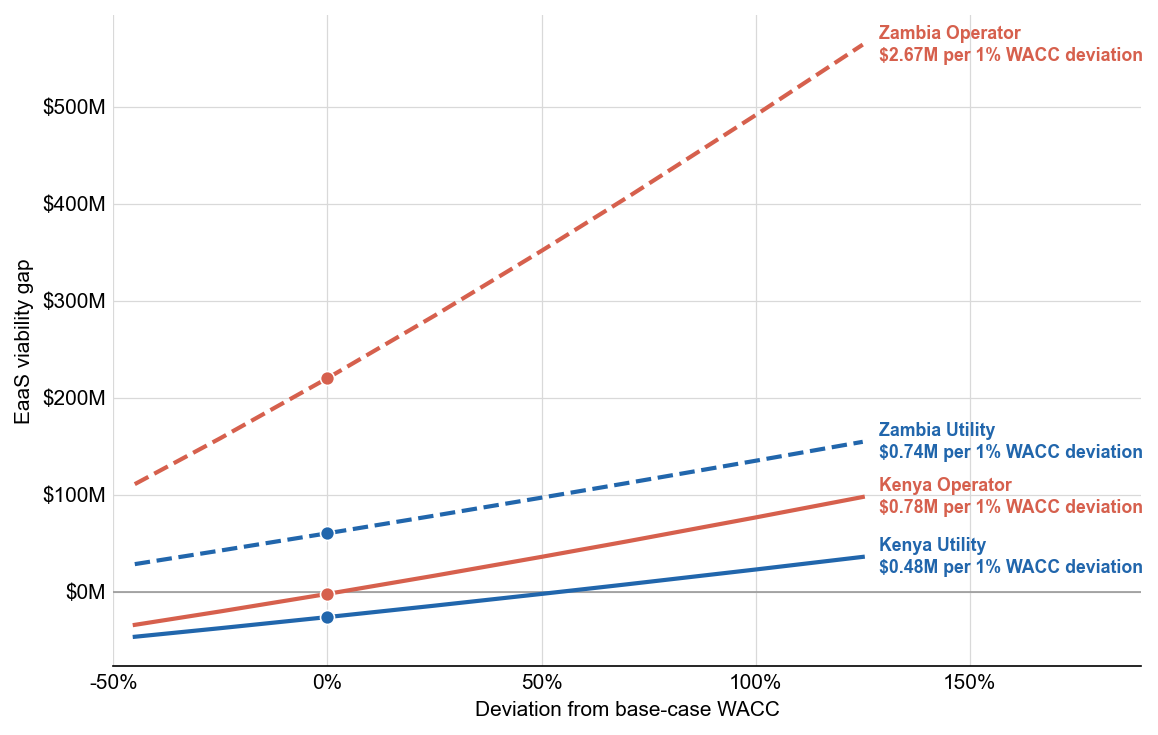

In [ ]:
def fig1_wacc_oat():
    ws = wb["WACC_sensitivity"]

    dev = np.array([ws.cell(r, 6).value for r in range(3, 11)], dtype=float)

    series = {
        "Kenya Utility":   ([ws.cell(r, 4).value for r in range(3, 11)],   COLOR_UTILITY, "-"),
        "Kenya Operator":  ([ws.cell(r, 4).value for r in range(11, 19)],  COLOR_OPERATOR, "-"),
        "Zambia Utility":  ([ws.cell(r, 4).value for r in range(19, 27)],  COLOR_UTILITY, "--"),
        "Zambia Operator": ([ws.cell(r, 4).value for r in range(27, 35)], COLOR_OPERATOR, "--"),
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    for label, (yvals, color, ls) in series.items():
        ax.plot(dev, yvals, color=color, linestyle=ls, linewidth=2)
        base_idx = list(dev).index(0.0)
        ax.scatter([0], [yvals[base_idx]], color=color, s=45, zorder=5, edgecolor="white", linewidth=0.8)

        dev_slope = (yvals[-1] - yvals[0]) / ((dev[-1] - dev[0]) * 100)  # $ per 1% deviation

        ax.annotate(f"{label}\n${dev_slope/1e6:,.2f}M per 1% WACC deviation",
                    xy=(dev[-1], yvals[-1]), xytext=(8, 0),
                    textcoords="offset points", va="center", ha="left",
                    color=color, fontsize=8.5, fontweight="bold", linespacing=1.3, clip_on=False)

    clean_axis(ax)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
    ax.set_xlabel("Deviation from base-case WACC")
    ax.set_ylabel("EaaS viability gap")
    ax.set_xlim(dev.min() - 0.05, dev.max() + 0.65)
    fig.tight_layout()
    save(fig, "fig1_wacc_oat_sensitivity")
    return fig

fig1_wacc_oat()
plt.show()
plt.close('all')

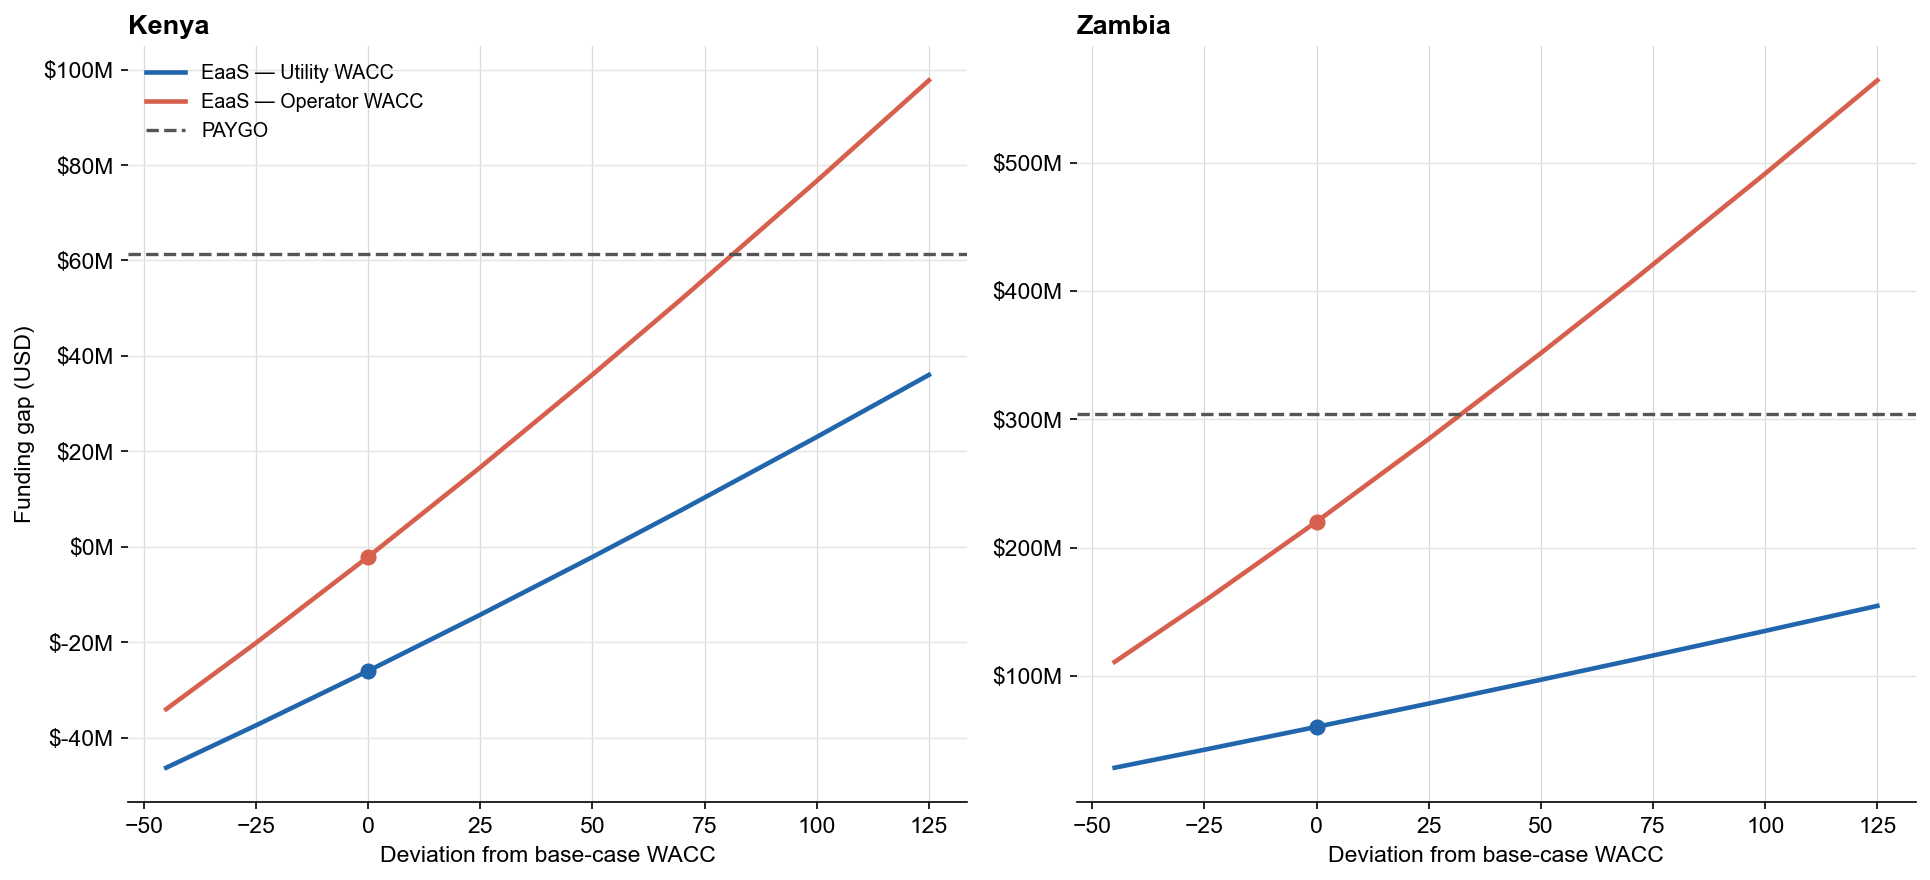

In [ ]:
offsets = np.array([-45, -25, 0, 25, 50, 70, 100, 125])  # % deviation from base WACC

kenya_utility = np.array([-46332224.56, -37464112.87, -26044791.68, -14270755.67,
                           -2159794.87, 7759695.77, 23002619.37, 36019758.06])
kenya_operator = np.array([-34064299.66, -20183563.56, -2135562.21, 16631288.33,
                            36058715.08, 52038526.97, 76673993.09, 97758624.30])
zambia_utility = np.array([28534214.57, 42530904.18, 60354487.02, 78533804.57,
                            97059759.34, 112123943.11, 135114874.78, 154625619.88])
zambia_operator = np.array([110976069.99, 158370749.76, 220200912.28, 284663111.18,
                             351507199.44, 406537854.64, 491410150.77, 564044519.50])

kenya_paygo = 61445073.52
zambia_paygo = 304214181.21

# --- Styling ---
COLOR_UTILITY = "#2166AC"
COLOR_OPERATOR = "#D6604D"
COLOR_PAYGO = "#555555"

def format_millions(x, pos):
    return f"${x/1e6:,.0f}M"

plt.rcParams['font.size'] = 11
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Panel 1: Kenya ---
ax = axes[0]
ax.plot(offsets, kenya_utility, color=COLOR_UTILITY, linewidth=2.2, label="EaaS — Utility WACC")
ax.plot(offsets, kenya_operator, color=COLOR_OPERATOR, linewidth=2.2, label="EaaS — Operator WACC")
ax.axhline(kenya_paygo, color=COLOR_PAYGO, linestyle="--", linewidth=1.6, label="PAYGO")

ax.scatter([0], [kenya_utility[2]], color=COLOR_UTILITY, zorder=5, s=45)
ax.scatter([0], [kenya_operator[2]], color=COLOR_OPERATOR, zorder=5, s=45)

ax.set_title("Kenya", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Deviation from base-case WACC")
ax.set_ylabel("Funding gap (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
ax.spines[['top','right']].set_visible(False)
ax.grid(axis="y", color="#e5e5e5", linewidth=0.7)
ax.legend(loc="upper left", frameon=False, fontsize=9.5)

# --- Panel 2: Zambia ---
ax = axes[1]
ax.plot(offsets, zambia_utility, color=COLOR_UTILITY, linewidth=2.2)
ax.plot(offsets, zambia_operator, color=COLOR_OPERATOR, linewidth=2.2)
ax.axhline(zambia_paygo, color=COLOR_PAYGO, linestyle="--", linewidth=1.6)

ax.scatter([0], [zambia_utility[2]], color=COLOR_UTILITY, zorder=5, s=45)
ax.scatter([0], [zambia_operator[2]], color=COLOR_OPERATOR, zorder=5, s=45)

ax.set_title("Zambia", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Deviation from base-case WACC")
ax.yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
ax.spines[['top','right']].set_visible(False)
ax.grid(axis="y", color="#e5e5e5", linewidth=0.7)

plt.tight_layout()
plt.savefig(OUT_DIR / "wacc_crossover_kenya_zambia.png", dpi=600, bbox_inches="tight")
plt.show()
plt.close('all')

Saved fig2_kenya_scenario_grid
Saved fig2_zambia_scenario_grid


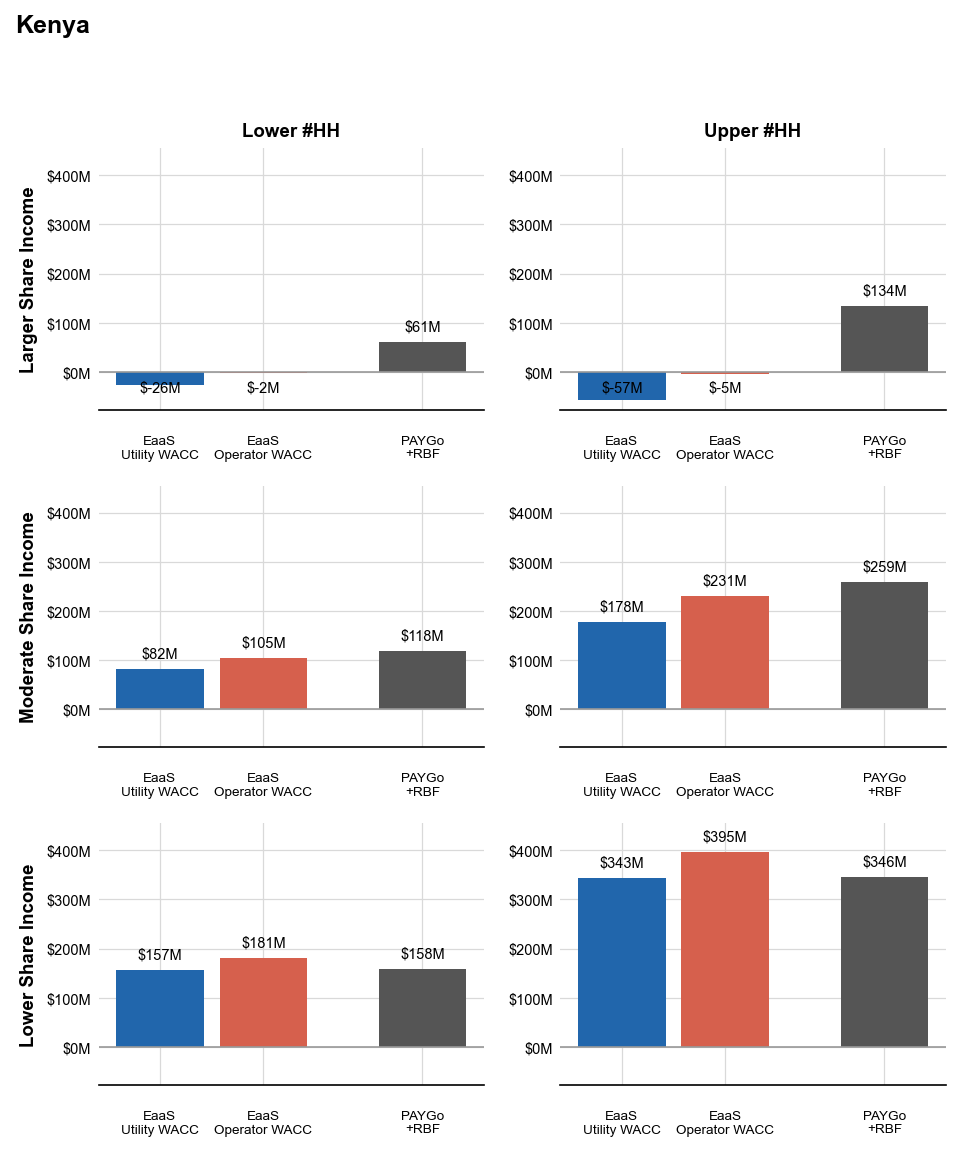

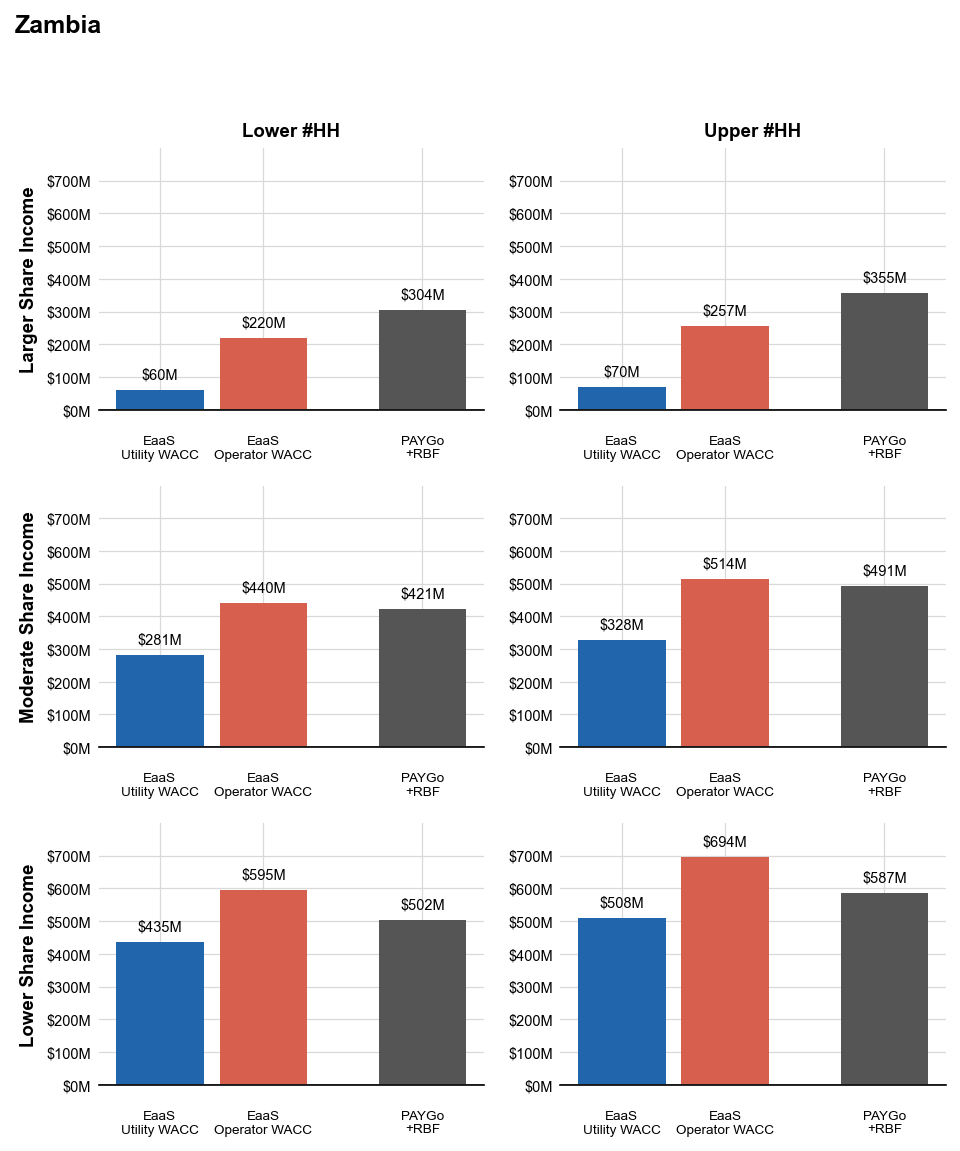

In [ ]:

def fig2_scenario_grid(country_label, cols, out_name):
    ws = wb["Sensitivity_Analysis"]

    op_rows = list(range(3, 9))
    ut_rows = list(range(9, 15))

    scenarios = []
    for r_op, r_ut in zip(op_rows, ut_rows):
        income = ws.cell(r_op, cols['income']).value
        hh = ws.cell(r_op, cols['hh']).value
        scenarios.append({
            "income": income, "hh": hh,
            "eaas_utility": ws.cell(r_ut, cols['eaas']).value,
            "eaas_operator": ws.cell(r_op, cols['eaas']).value,
            "paygo": ws.cell(r_op, cols['paygo']).value,
        })

    income_order = ["Upper Bound", "Middle Bound", "Lower Bound"]
    hh_order = ["Upper Bound", "Lower Bound"]


    
    hh_display_label = {"Upper Bound": "Lower Bound", "Lower Bound": "Upper Bound"}
    income_display_label = {
        "Upper Bound": "Larger Share",
        "Middle Bound": "Moderate Share",
        "Lower Bound": "Lower Share",
    }

    x_positions = [0, 0.65, 1.65]
    bar_labels = ["EaaS\nUtility WACC", "EaaS\nOperator WACC", "PAYGo\n+RBF"]
    bar_colors = [COLOR_UTILITY, COLOR_OPERATOR, COLOR_PAYGO]

    all_vals = [v for s in scenarios for v in (s["eaas_utility"], s["eaas_operator"], s["paygo"])]
    ymin_global = min(0, min(all_vals))
    ymax_global = max(all_vals)
    pad_bottom = abs(ymin_global) * 0.35 if ymin_global < 0 else 0
    pad_top = ymax_global * 0.15
    ylim = (ymin_global - pad_bottom, ymax_global + pad_top)

    fig, axes = plt.subplots(3, 2, figsize=(6.5, 7.8), sharey=True)

    for i, inc in enumerate(income_order):
        for j, hh in enumerate(hh_order):
            ax = axes[i, j]
            s = next(sc for sc in scenarios if sc["income"] == inc and sc["hh"] == hh)
            vals = [s["eaas_utility"], s["eaas_operator"], s["paygo"]]

            bars = ax.bar(x_positions, vals, color=bar_colors, width=0.55)

            for xpos, v in zip(x_positions, vals):
                if v >= 0:
                    ax.annotate(f"${v/1e6:,.0f}M", xy=(xpos, v),
                                xytext=(0, 4), textcoords="offset points",
                                ha="center", va="bottom", fontsize=7, clip_on=False)
                else:
                    ax.annotate(f"${v/1e6:,.0f}M", xy=(xpos, 0),
                                xytext=(0, -4), textcoords="offset points",
                                ha="center", va="top", fontsize=7, clip_on=False)

            clean_axis(ax, y_money=True)
            ax.set_xticks(x_positions)
            ax.set_xticklabels(bar_labels, fontsize=6.5)
            ax.tick_params(axis="x", pad=12)
            ax.tick_params(axis="y", labelleft=True, labelsize=7)
            ax.set_ylim(*ylim)

            if i == 0:
                ax.set_title(f"{hh_display_label[hh].split()[0]} #HH", fontsize=9, fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"{income_display_label[inc]} Income", fontsize=9, fontweight="bold")

    fig.suptitle(country_label, fontsize=12, fontweight="bold", x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save(fig, out_name)
    return fig

def fig2_kenya_grid():
    return fig2_scenario_grid(
        "Kenya",
        {'income': 3, 'hh': 4, 'eaas': 5, 'paygo': 6},
        "fig2_kenya_scenario_grid",
    )

def fig2_zambia_grid():
    return fig2_scenario_grid(
        "Zambia",
        {'income': 10, 'hh': 11, 'eaas': 12, 'paygo': 13},
        "fig2_zambia_scenario_grid",
    )

fig2_kenya_grid()
fig2_zambia_grid()
plt.show()
plt.close('all')

Saved fig2_base_case_mtf


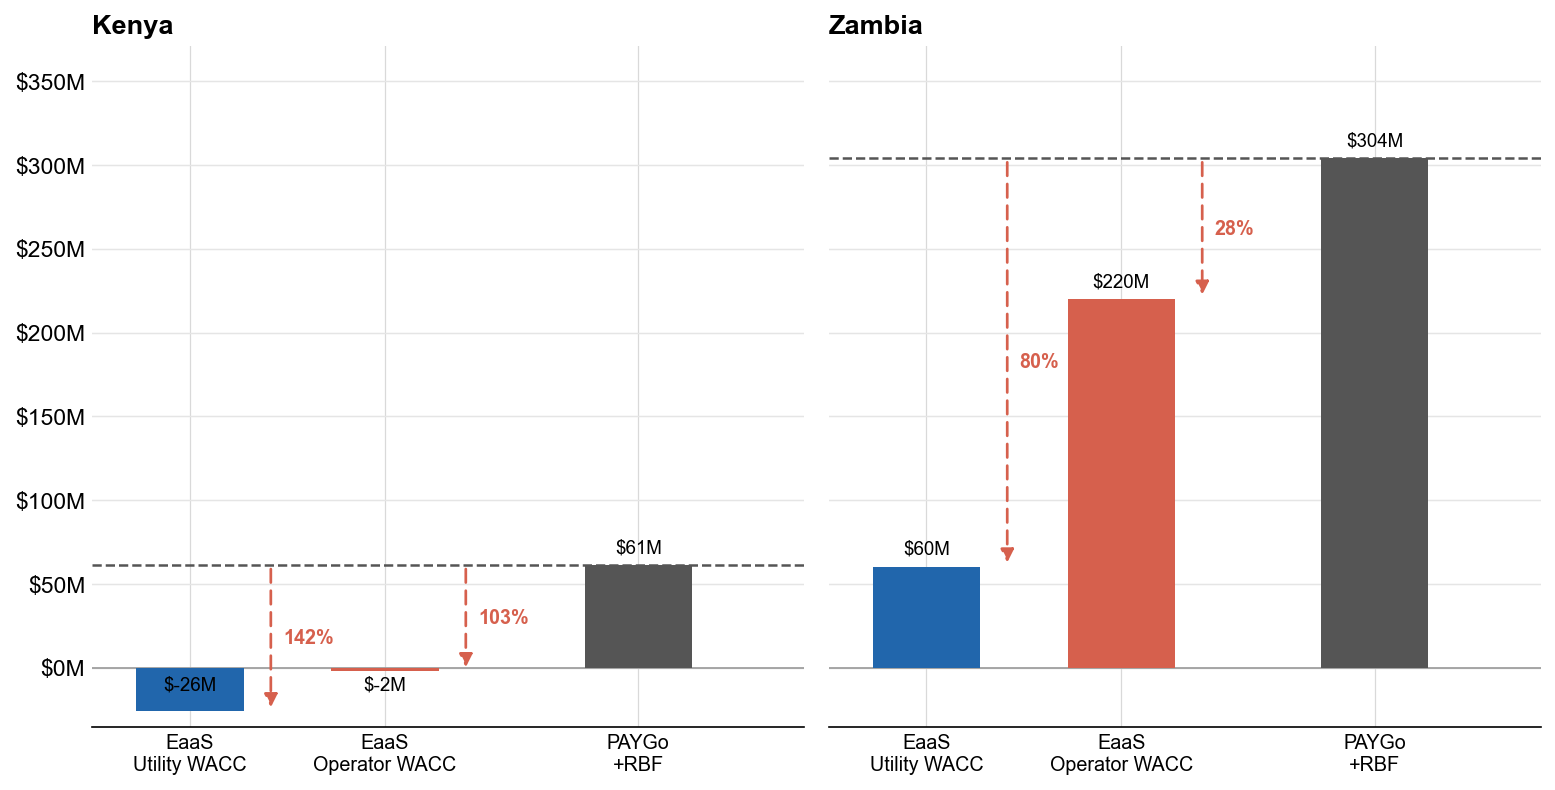

In [ ]:
def fig2_base_case_with_pct():
    ws = wb["Sensitivity_Analysis"]

    ACTIVE_HH_LABEL     = "Upper Bound"   # tagged MTF in Assumptions source note
    ACTIVE_INCOME_LABEL = "Upper Bound"   # 10% threshold (Scenario A)

    country_cols = {
        "Kenya":  {'wacc': 2, 'income': 3,  'hh': 4,  'eaas': 5,  'paygo': 6},
        "Zambia": {'wacc': 9, 'income': 10, 'hh': 11, 'eaas': 12, 'paygo': 13},
    }

    def get_scenario_row(cols, wacc_label):
        for r in range(3, 15):
            if (ws.cell(r, cols['wacc']).value == wacc_label and
                ws.cell(r, cols['income']).value == ACTIVE_INCOME_LABEL and
                ws.cell(r, cols['hh']).value == ACTIVE_HH_LABEL):
                return ws.cell(r, cols['eaas']).value, ws.cell(r, cols['paygo']).value
        raise ValueError(f"No row found for WACC='{wacc_label}', Income='{ACTIVE_INCOME_LABEL}', HH='{ACTIVE_HH_LABEL}'")

    bar_labels = ["EaaS\nUtility WACC", "EaaS\nOperator WACC", "PAYGo\n+RBF"]
    bar_colors = [COLOR_UTILITY, COLOR_OPERATOR, COLOR_PAYGO]
    x_positions = [0, 1.0, 2.3]
    bar_width = 0.55
    ARROW_OFFSET = bar_width / 2 + 0.14

    ARROW_UP_COLOR   = COLOR_UTILITY
    ARROW_DOWN_COLOR = COLOR_OPERATOR

    base_case = {}
    for country, cols in country_cols.items():
        eaas_utility,  paygo_u = get_scenario_row(cols, "Utility")
        eaas_operator, paygo_o = get_scenario_row(cols, "Operator")
        assert abs(paygo_u - paygo_o) < 1, "PAYGo should be identical regardless of WACC scenario"
        base_case[country] = {
            "eaas_utility":  eaas_utility,
            "eaas_operator": eaas_operator,
            "paygo":         paygo_u,
        }

    all_vals = [v for s in base_case.values() for v in s.values()]
    ymin, ymax = min(0, min(all_vals)), max(all_vals)
    pad_bottom = abs(ymin) * 0.35 if ymin < 0 else 0
    ylim = (ymin - pad_bottom, ymax * 1.22)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.4), sharey=True)

    for ax, (country, s) in zip(axes, base_case.items()):
        vals = [s["eaas_utility"], s["eaas_operator"], s["paygo"]]
        paygo_val = s["paygo"]

        ax.bar(x_positions, vals, color=bar_colors, width=bar_width, zorder=3)

        for xpos, v in zip(x_positions, vals):
            if v >= 0:
                ax.annotate(f"${v/1e6:,.0f}M", xy=(xpos, v), xytext=(0, 4),
                            textcoords="offset points", ha="center", va="bottom", fontsize=9)
            else:
                ax.annotate(f"${v/1e6:,.0f}M", xy=(xpos, 0), xytext=(0, -4),
                            textcoords="offset points", ha="center", va="top", fontsize=9)

        for xpos, v in zip(x_positions[:2], vals[:2]):
            pct_change = abs((v - paygo_val) / paygo_val) * 100
            arrow_color = ARROW_UP_COLOR if v > paygo_val else ARROW_DOWN_COLOR
            ax_x = xpos + ARROW_OFFSET

            ax.annotate('', xy=(ax_x, v), xytext=(ax_x, paygo_val),
                        arrowprops=dict(arrowstyle='-|>', color=arrow_color, lw=1.3,
                                        linestyle=(0, (5, 3)), mutation_scale=13))
            ax.annotate(f"{pct_change:.0f}%", xy=(ax_x, (v + paygo_val) / 2),
                        xytext=(6, 0), textcoords="offset points",
                        ha="left", va="center", fontsize=9.5, fontweight="bold", color=arrow_color)

        ax.axhline(paygo_val, color=COLOR_PAYGO, linestyle="--", linewidth=1.2, zorder=1)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bar_labels, fontsize=9.5)
        ax.set_ylim(*ylim)
        ax.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.85)
        ax.axhline(0, color="#999999", linewidth=0.8, zorder=1)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
        ax.set_title(country, fontsize=13, fontweight="bold", loc="left")
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis="both", length=0)
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.7, zorder=0)

  
    fig.tight_layout()
    save(fig, "fig2_base_case_mtf")
    return fig

fig2_base_case_with_pct()
plt.show()
plt.close('all')

Saved fig2_mtf_5pct_income


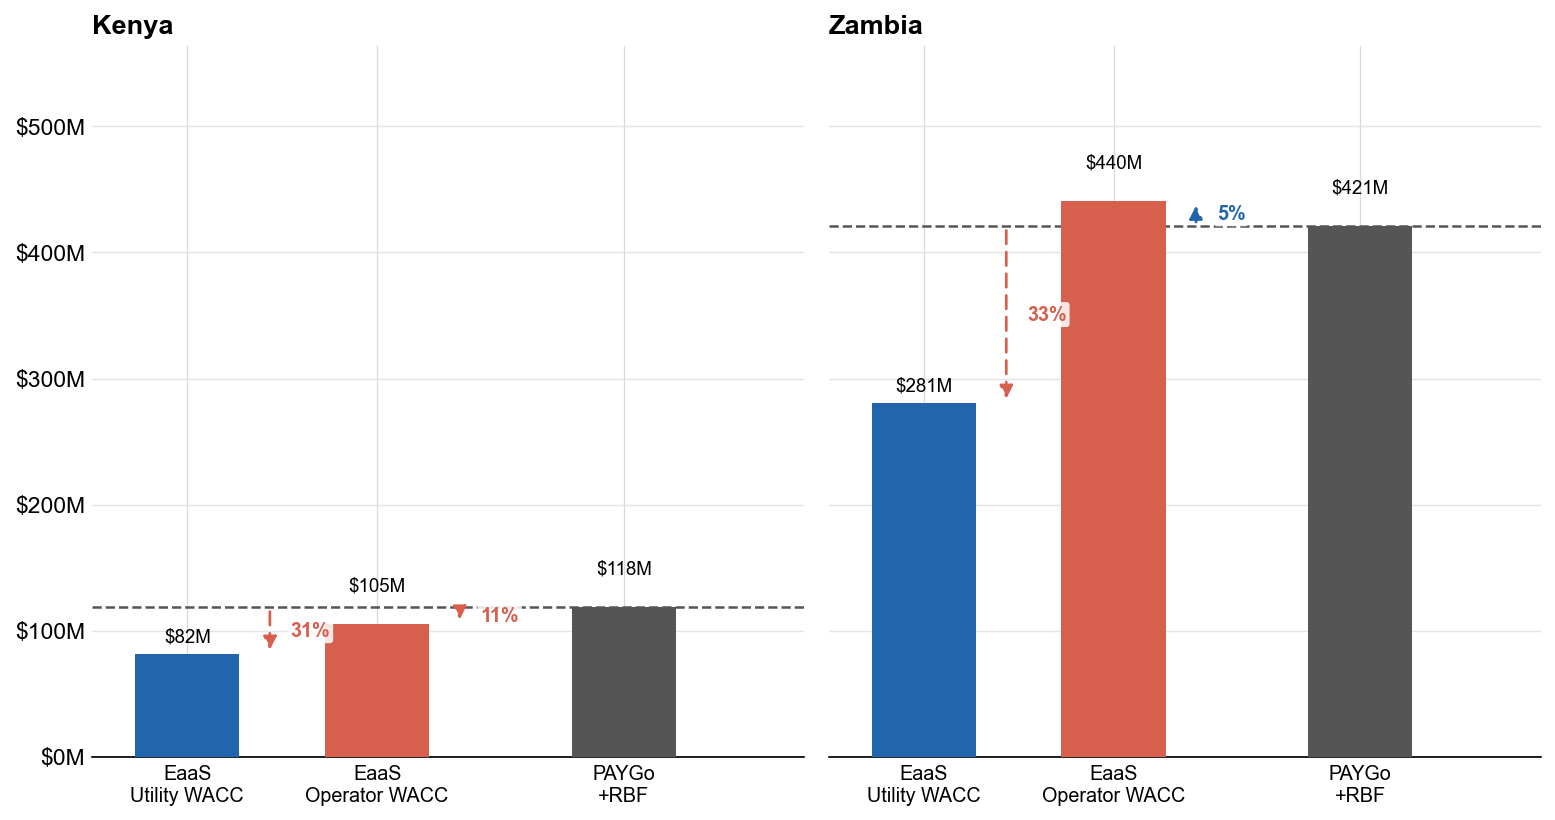

In [ ]:
def fig2_base_case_with_pct():
    ws = wb["Sensitivity_Analysis"]

    ACTIVE_HH_LABEL     = "Upper Bound"
    ACTIVE_INCOME_LABEL = "Middle Bound"

    country_cols = {
        "Kenya":  {'wacc': 2, 'income': 3,  'hh': 4,  'eaas': 5,  'paygo': 6},
        "Zambia": {'wacc': 9, 'income': 10, 'hh': 11, 'eaas': 12, 'paygo': 13},
    }

    def get_scenario_row(cols, wacc_label):
        for r in range(3, 15):
            if (ws.cell(r, cols['wacc']).value == wacc_label and
                ws.cell(r, cols['income']).value == ACTIVE_INCOME_LABEL and
                ws.cell(r, cols['hh']).value == ACTIVE_HH_LABEL):
                return ws.cell(r, cols['eaas']).value, ws.cell(r, cols['paygo']).value
        raise ValueError(f"No row found for WACC='{wacc_label}', Income='{ACTIVE_INCOME_LABEL}', HH='{ACTIVE_HH_LABEL}'")

    bar_labels = ["EaaS\nUtility WACC", "EaaS\nOperator WACC", "PAYGo\n+RBF"]
    bar_colors = [COLOR_UTILITY, COLOR_OPERATOR, COLOR_PAYGO]
    x_positions = [0, 1.0, 2.3]
    bar_width = 0.55
    ARROW_OFFSET = bar_width / 2 + 0.16

    ARROW_UP_COLOR   = COLOR_UTILITY
    ARROW_DOWN_COLOR = COLOR_OPERATOR

    base_case = {}
    for country, cols in country_cols.items():
        eaas_utility,  paygo_u = get_scenario_row(cols, "Utility")
        eaas_operator, paygo_o = get_scenario_row(cols, "Operator")
        assert abs(paygo_u - paygo_o) < 1, "PAYGo should be identical regardless of WACC scenario"
        base_case[country] = {
            "eaas_utility":  eaas_utility,
            "eaas_operator": eaas_operator,
            "paygo":         paygo_u,
        }

    all_vals = [v for s in base_case.values() for v in s.values()]
    ymin, ymax = min(0, min(all_vals)), max(all_vals)
    pad_bottom = abs(ymin) * 0.35 if ymin < 0 else 0
    ylim = (ymin - pad_bottom, ymax * 1.28)   # more top padding for upward arrows/labels

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.6), sharey=True)

    for ax, (country, s) in zip(axes, base_case.items()):
        vals = [s["eaas_utility"], s["eaas_operator"], s["paygo"]]
        paygo_val = s["paygo"]
        y_range = ylim[1] - ylim[0]

        ax.bar(x_positions, vals, color=bar_colors, width=bar_width, zorder=3)

        for xpos, v in zip(x_positions, vals):
            close_to_baseline = abs(v - paygo_val) / y_range < 0.045   # within ~4.5% of plot height
            if v >= 0:
                offset_pts = 14 if close_to_baseline else 4
                ax.annotate(f"${v/1e6:,.0f}M", xy=(xpos, v), xytext=(0, offset_pts),
                            textcoords="offset points", ha="center", va="bottom", fontsize=9)
            else:
                ax.annotate(f"${v/1e6:,.0f}M", xy=(xpos, 0), xytext=(0, -4),
                            textcoords="offset points", ha="center", va="top", fontsize=9)

        for xpos, v in zip(x_positions[:2], vals[:2]):
            pct_change = abs((v - paygo_val) / paygo_val) * 100
            arrow_color = ARROW_UP_COLOR if v > paygo_val else ARROW_DOWN_COLOR
            ax_x = xpos + ARROW_OFFSET

            ax.annotate('', xy=(ax_x, v), xytext=(ax_x, paygo_val),
                        arrowprops=dict(arrowstyle='-|>', color=arrow_color, lw=1.3,
                                        linestyle=(0, (5, 3)), mutation_scale=13))

            label_y = (v + paygo_val) / 2
            ax.annotate(f"{pct_change:.0f}%", xy=(ax_x, label_y),
                        xytext=(10, 0), textcoords="offset points",
                        ha="left", va="center", fontsize=9.5, fontweight="bold", color=arrow_color,
                        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.85))

        ax.axhline(paygo_val, color=COLOR_PAYGO, linestyle="--", linewidth=1.2, zorder=1)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bar_labels, fontsize=9.5)
        ax.set_ylim(*ylim)
        ax.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.95)
        ax.axhline(0, color="#999999", linewidth=0.8, zorder=1)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
        ax.set_title(country, fontsize=13, fontweight="bold", loc="left")
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis="both", length=0)
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.7, zorder=0)


    fig.tight_layout()
    save(fig, "fig2_mtf_5pct_income")
    return fig

fig2_base_case_with_pct()
plt.show()
plt.close('all')

Saved fig3_kenya_levy_pie_grid
Saved fig3_zambia_levy_pie_grid


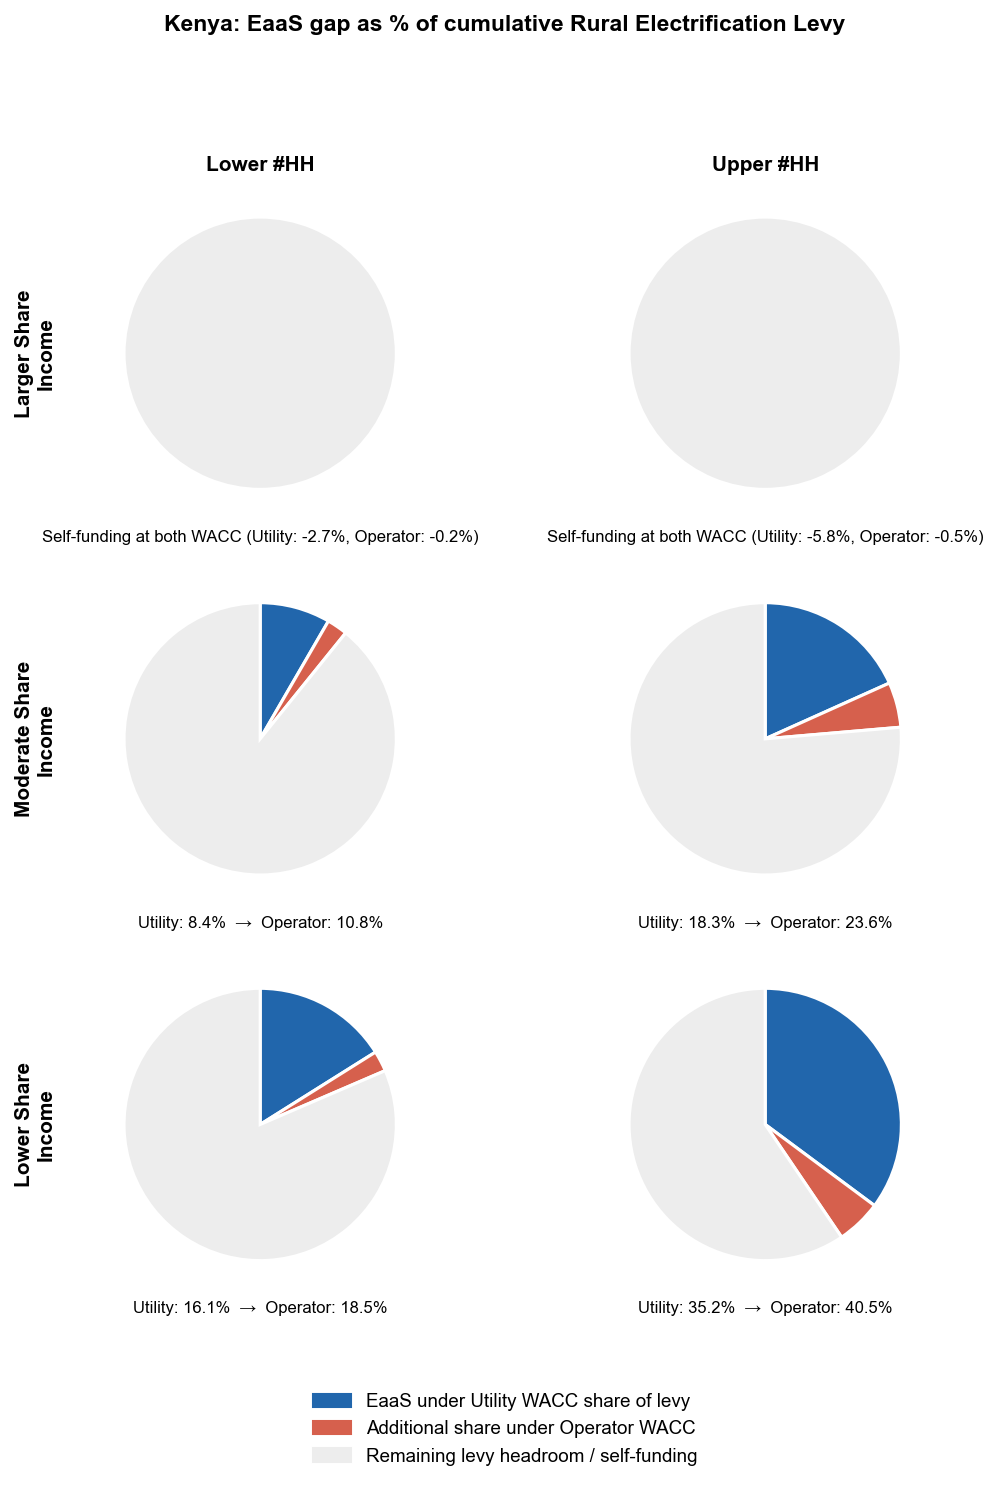

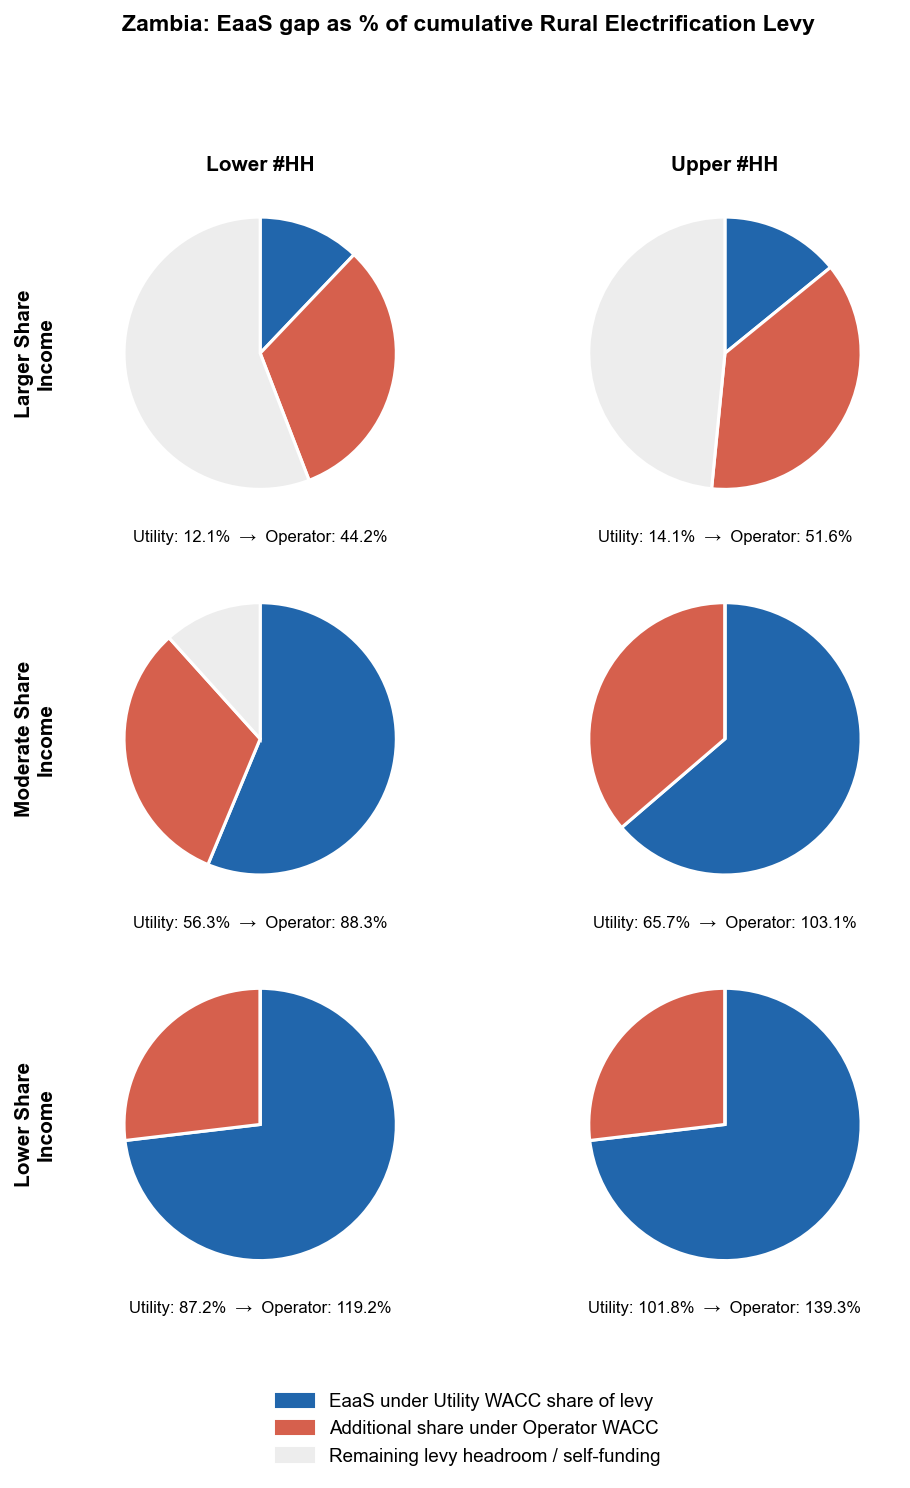

In [ ]:
def fig3_levy_pie_grid(country_label, ws_cols, levy_cell_row, out_name):
    ws = wb["Sensitivity_Analysis"]
    model_sheet = wb[f"Model_{country_label}_2025"]

    cum_levy = model_sheet.cell(levy_cell_row, 13).value

    op_rows = list(range(3, 9))
    ut_rows = list(range(9, 15))

    scenarios = []
    for r_op, r_ut in zip(op_rows, ut_rows):
        income = ws.cell(r_op, ws_cols['income']).value
        hh = ws.cell(r_op, ws_cols['hh']).value
        gap_operator = ws.cell(r_op, ws_cols['eaas']).value
        gap_utility = ws.cell(r_ut, ws_cols['eaas']).value
        scenarios.append({
            "income": income, "hh": hh,
            "pct_utility": gap_utility / cum_levy * 100,
            "pct_operator": gap_operator / cum_levy * 100,
        })

    income_order = ["Upper Bound", "Middle Bound", "Lower Bound"]
    hh_order = ["Upper Bound", "Lower Bound"]
    remainder_color = "#EDEDED"

    hh_display_label = {"Upper Bound": "Lower Bound", "Lower Bound": "Upper Bound"}
    income_display_label = {
            "Upper Bound": "Larger Share",
            "Middle Bound": "Moderate Share",
            "Lower Bound": "Lower Share",
        }

    fig, axes = plt.subplots(3, 2, figsize=(7, 9.5))

    for i, inc in enumerate(income_order):
        for j, hh in enumerate(hh_order):
            ax = axes[i, j]
            s = next(sc for sc in scenarios if sc["income"] == inc and sc["hh"] == hh)

            pu = s["pct_utility"]
            po = s["pct_operator"]

            
            base = max(0, pu)
            increase = max(0, po) - base if po > 0 else 0
            increase = max(0, increase)
            remainder = max(0, 100 - base - increase)

            wedges, _ = ax.pie(
                [base, increase, remainder],
                colors=[COLOR_UTILITY, COLOR_OPERATOR, remainder_color],
                startangle=90, counterclock=False,
                wedgeprops=dict(edgecolor="white", linewidth=1.5),
            )

            ax.set_aspect("equal")

            if pu <= 0 and po <= 0:
                label = f"Self-funding at both WACC (Utility: {pu:.1f}%, Operator: {po:.1f}%)"
            elif pu <= 0:
                label = f"Utility: self-funding ({pu:.1f}%)  →  Operator: {po:.1f}%"
            else:
                label = f"Utility: {pu:.1f}%  →  Operator: {po:.1f}%"

            ax.text(0, -1.35, label, ha="center", va="center", fontsize=8)

            if i == 0:
                ax.set_title(f"{hh_display_label[hh].split()[0]} #HH", fontsize=10, fontweight="bold")
            if j == 0:
                ax.text(-1.65, 0, f"{income_display_label[inc]}\nIncome", ha="center", va="center",
                        fontsize=10, fontweight="bold", rotation=90)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(color=COLOR_UTILITY, label="EaaS under Utility WACC share of levy"),
        Patch(color=COLOR_OPERATOR, label="Additional share under Operator WACC"),
        Patch(color=remainder_color, label="Remaining levy headroom / self-funding"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=1, frameon=False,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)

    fig.suptitle(f"{country_label}: EaaS gap as % of cumulative Rural Electrification Levy",
                 fontsize=11, fontweight="bold", x=0.5, ha="center")
    fig.tight_layout(rect=[0, 0.05, 1, 0.93])
    save(fig, out_name)
    return fig

def fig3_kenya_pie():
    return fig3_levy_pie_grid(
        "Kenya", {'income': 3, 'hh': 4, 'eaas': 5}, levy_cell_row=14,
        out_name="fig3_kenya_levy_pie_grid",
    )

def fig3_zambia_pie():
    return fig3_levy_pie_grid(
        "Zambia", {'income': 10, 'hh': 11, 'eaas': 12}, levy_cell_row=14,
        out_name="fig3_zambia_levy_pie_grid",
    )

fig3_kenya_pie()
fig3_zambia_pie()
plt.show()
plt.close('all')

Saved fig_levy_capture_comparison


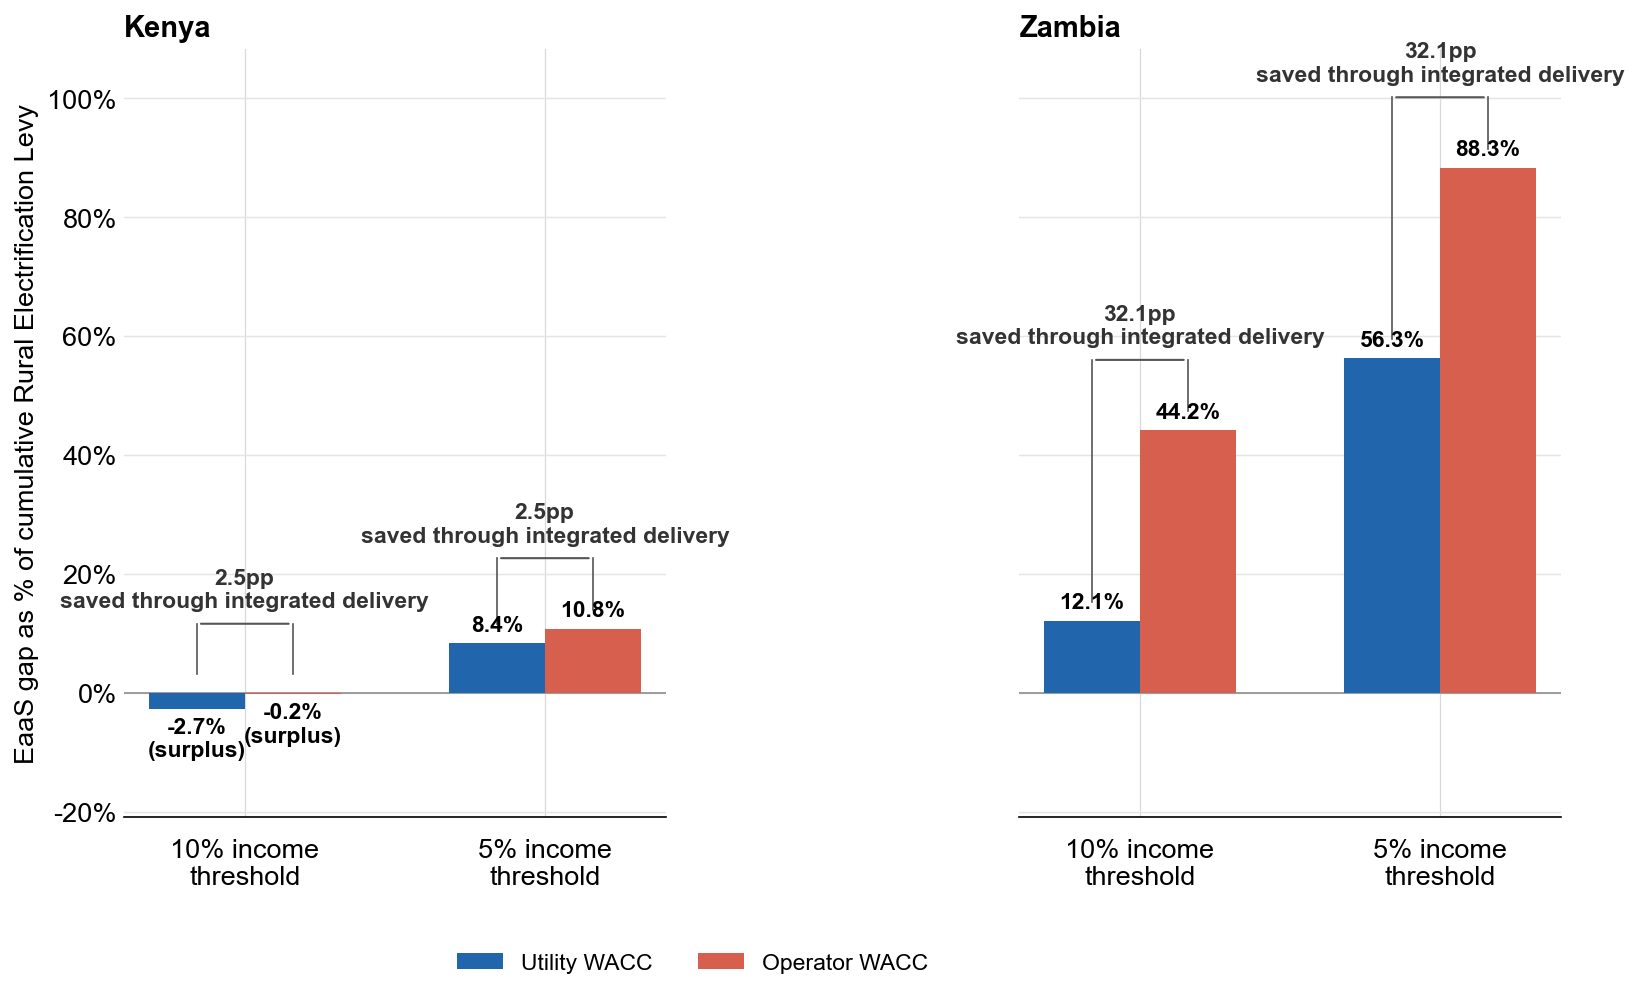

In [ ]:
def fig_levy_capture_comparison():
    ws = wb["Sensitivity_Analysis"]

    ACTIVE_HH_LABEL = "Upper Bound"  

    income_scenarios = [
        ("Upper Bound", "10% income\nthreshold"),
        ("Middle Bound", "5% income\nthreshold"),
    ]

    country_cols = {
        "Kenya":  {'wacc': 2, 'income': 3,  'hh': 4,  'eaas': 5,  'levy_row': 14},
        "Zambia": {'wacc': 9, 'income': 10, 'hh': 11, 'eaas': 12, 'levy_row': 14},
    }

    def get_eaas_gap(cols, wacc_label, income_label):
        for r in range(3, 15):
            if (ws.cell(r, cols['wacc']).value == wacc_label and
                ws.cell(r, cols['income']).value == income_label and
                ws.cell(r, cols['hh']).value == ACTIVE_HH_LABEL):
                return ws.cell(r, cols['eaas']).value
        raise ValueError(f"No row found for WACC='{wacc_label}', Income='{income_label}', HH='{ACTIVE_HH_LABEL}'")

    results = {}
    for country, cols in country_cols.items():
        model_sheet = wb[f"Model_{country}_2025"]
        cum_levy = model_sheet.cell(cols['levy_row'], 13).value

        results[country] = {}
        for income_label, income_display in income_scenarios:
            pct_utility  = get_eaas_gap(cols, "Utility",  income_label) / cum_levy * 100
            pct_operator = get_eaas_gap(cols, "Operator", income_label) / cum_levy * 100
            results[country][income_display] = {"Utility": pct_utility, "Operator": pct_operator}

    all_vals_global = [v for country in results.values() for scen in country.values() for v in scen.values()]
    ymin_global = min(0, min(all_vals_global))
    ymax_global = max(all_vals_global)
    yr_global = ymax_global - ymin_global
    shared_ylim = (ymin_global - yr_global * 0.20, ymax_global + yr_global * 0.22)

    fig, axes = plt.subplots(1, 2, figsize=(11, 6.8), sharey=True)
    bar_width = 0.32
    x_group = np.arange(len(income_scenarios))

    for ax, country in zip(axes, country_cols):
        util_vals = [results[country][disp]["Utility"] for _, disp in income_scenarios]
        op_vals   = [results[country][disp]["Operator"] for _, disp in income_scenarios]

        bars_u = ax.bar(x_group - bar_width/2, util_vals, width=bar_width,
                         color=COLOR_UTILITY, label="Utility WACC", zorder=3)
        bars_o = ax.bar(x_group + bar_width/2, op_vals, width=bar_width,
                         color=COLOR_OPERATOR, label="Operator WACC", zorder=3)

        for bars, vals in [(bars_u, util_vals), (bars_o, op_vals)]:
            for bar, v in zip(bars, vals):
                va = "bottom" if v >= 0 else "top"
                offset = 4 if v >= 0 else -4
                label = f"{v:.1f}%" if v >= 0 else f"{v:.1f}%\n(surplus)"
                ax.annotate(label, xy=(bar.get_x() + bar.get_width()/2, v),
                            xytext=(0, offset), textcoords="offset points",
                            ha="center", va=va, fontsize=11, fontweight="bold")

        label_clearance = yr_global * 0.035   # vertical gap so drop-lines stop short of $/% labels
        for i, (util_v, op_v) in enumerate(zip(util_vals, op_vals)):
            gap = op_v - util_v
            bar_top = max(util_v, op_v)
            bracket_y_top = bar_top + yr_global * 0.13

            ax.annotate('', xy=(x_group[i] - bar_width/2, bracket_y_top),
                        xytext=(x_group[i] + bar_width/2, bracket_y_top),
                        arrowprops=dict(arrowstyle='-', color='#555555', lw=1))

            ax.plot([x_group[i] - bar_width/2]*2,
                     [bracket_y_top, max(util_v, 0) + label_clearance], color='#555555', lw=0.8)
            ax.plot([x_group[i] + bar_width/2]*2,
                     [bracket_y_top, max(op_v, 0) + label_clearance], color='#555555', lw=0.8)
            ax.annotate(f"{gap:.1f}pp\nsaved through integrated delivery", xy=(x_group[i], bracket_y_top),
                        xytext=(0, 6), textcoords="offset points",
                        ha="center", va="bottom", fontsize=11, fontweight="bold", color="#333333")

        ax.set_ylim(*shared_ylim)
        ax.axhline(0, color="#999999", linewidth=0.9, zorder=1)
        ax.set_xticks(x_group)
        ax.set_xticklabels([disp for _, disp in income_scenarios], fontsize=13)
        ax.tick_params(axis='x', pad=10)
        ax.tick_params(axis='y', labelsize=13)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
        ax.set_title(country, fontsize=14, fontweight="bold", loc="left")
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis="both", length=0)
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.7, zorder=0)

    axes[0].set_ylabel("EaaS gap as % of cumulative Rural Electrification Levy", fontsize=13)
    axes[0].legend(loc="upper center", bbox_to_anchor=(1.05, -0.15), ncol=2, frameon=False, fontsize=11)

    fig.tight_layout()
    save(fig, "fig_levy_capture_comparison")
    return fig

fig_levy_capture_comparison()
plt.show()
plt.close('all')

Saved fig6_variance_decomposition


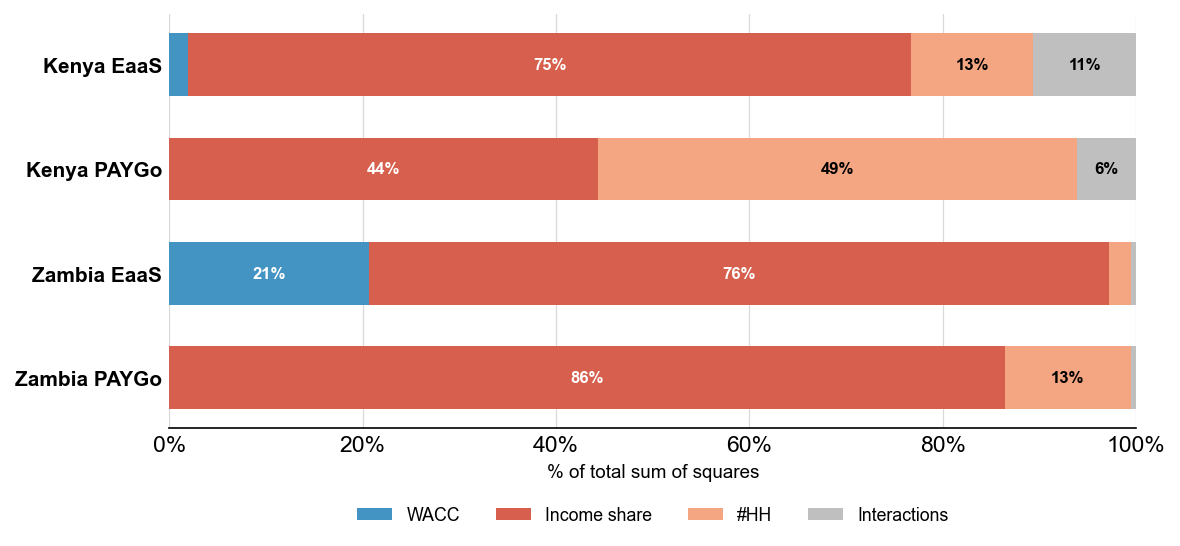

In [ ]:
def fig6_variance_decomposition():
    ws = wb["Sensitivity_Analysis"]
    labels = ["Kenya EaaS", "Kenya PAYGo", "Zambia EaaS", "Zambia PAYGo"]
    rows = [95, 96, 97, 98]

    wacc  = [ws.cell(r, 2).value * 100 for r in rows]
    inc   = [ws.cell(r, 3).value * 100 for r in rows]
    hh    = [ws.cell(r, 4).value * 100 for r in rows]
    inter = [ws.cell(r, 5).value * 100 for r in rows]

    y = np.arange(len(labels))[::-1]
    fig, ax = plt.subplots(figsize=(8, 3.8))

    left = np.zeros(len(labels))
    segments = [
        (wacc,  "#4393C3", "WACC"),
        (inc,   COLOR_OPERATOR, "Income share"),
        (hh,    "#F4A582", "#HH"),
        (inter, "#BFBFBF", "Interactions"),
    ]

    for vals, color, name in segments:
        bars = ax.barh(y, vals, left=left, color=color, label=name, height=0.6)
        for yi, v, l in zip(y, vals, left):
            if v >= 6:  # only label segments big enough to hold text legibly
                text_color = "white" if color in (COLOR_OPERATOR, "#4393C3") else "black"
                ax.annotate(f"{v:.0f}%", xy=(l + v / 2, yi), ha="center", va="center",
                            fontsize=8, color=text_color, fontweight="bold")
        left += np.array(vals)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10, fontweight="bold")
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
    ax.tick_params(axis="both", length=0)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4,
              frameon=False, fontsize=8.5)

    ax.set_xlabel("% of total sum of squares", fontsize=9)

    fig.tight_layout()
    save(fig, "fig6_variance_decomposition")
    return fig

fig6_variance_decomposition()
plt.show()
plt.close('all')

Saved figX_zambia_investment_story


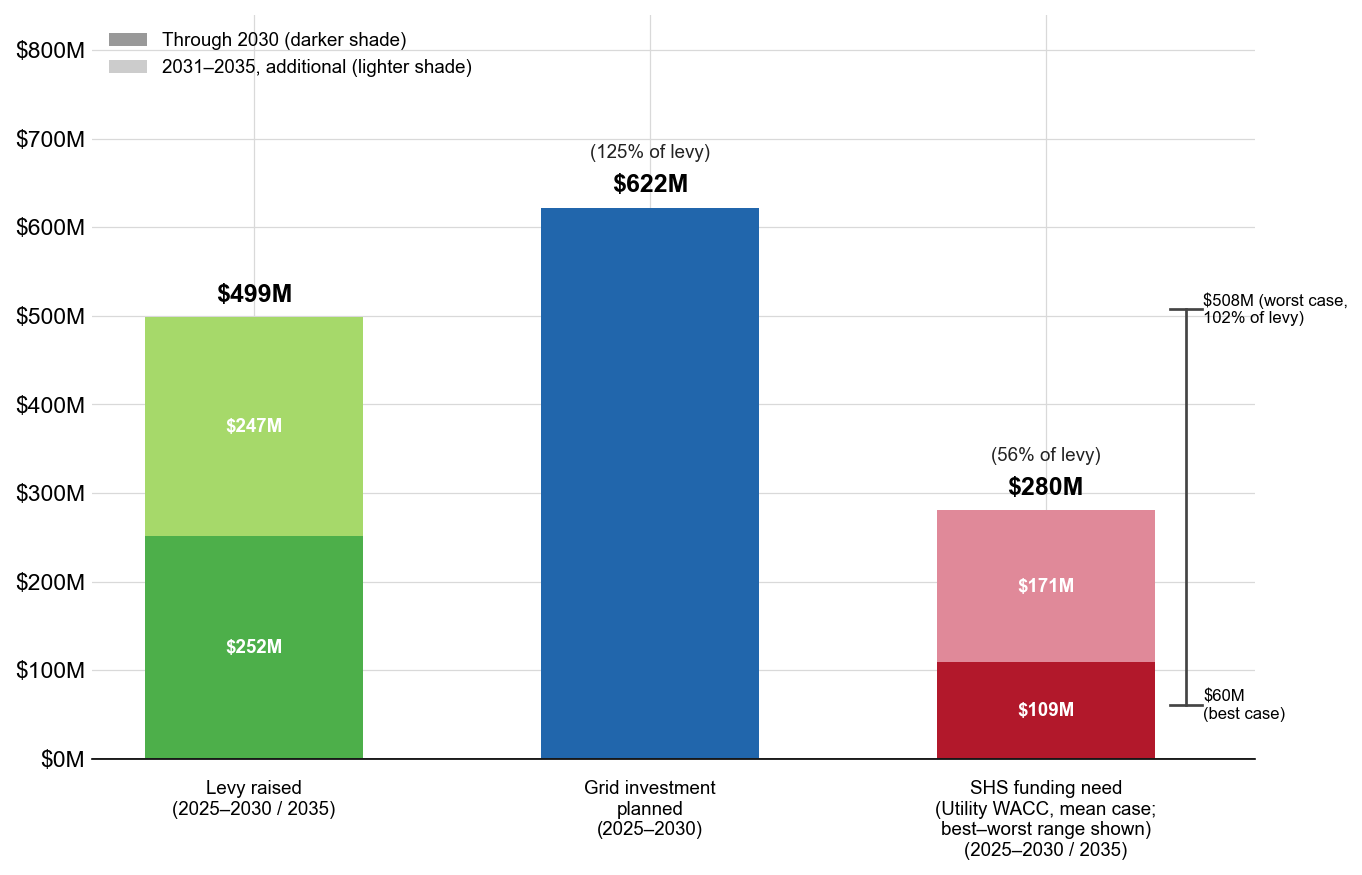

In [ ]:
def fig_zambia_investment_story():
    ws = wb["Model_Zambia_2025"]
    sens = wb["Sensitivity_Analysis"]
    TOTAL_COL = 13

    grid_total     = ws.cell(21, TOTAL_COL).value
    minigrid_total = ws.cell(22, TOTAL_COL).value
    shs_total      = ws.cell(23, TOTAL_COL).value
    grand_total    = ws.cell(25, TOTAL_COL).value
    assert abs((grid_total + minigrid_total + shs_total) - grand_total) < 1

    
    levy_2030 = sum(ws.cell(14, c).value for c in range(2, 8))
    levy_2035 = ws.cell(14, TOTAL_COL).value
    levy_extra = levy_2035 - levy_2030

    utility_rows = list(range(9, 15))
    utility_gaps = [sens.cell(r, 12).value for r in utility_rows]

    min_gap = min(utility_gaps)                          # best case within Utility WACC
    max_gap = max(utility_gaps)                           # worst case within Utility WACC
    central_gap = sum(utility_gaps) / len(utility_gaps)    # mean across the 6 scenarios

    cum_conn = [ws.cell(4, c).value for c in range(2, 13)]  # 2025-2035
    weight_2030 = sum(cum_conn[0:6]) / sum(cum_conn)
    shs_gap_2030 = central_gap * weight_2030
    shs_gap_2031_2035 = central_gap - shs_gap_2030

    COLOR_GRID = "#2166AC"
    COLOR_SHS, COLOR_SHS_LIGHT = "#B2182B", "#E08999"
    COLOR_LEVY, COLOR_LEVY_LIGHT = "#4DAF4A", "#A6D96A"

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.subplots_adjust(top=0.80, bottom=0.18)

    x = [0, 1, 2]
    bar_w = 0.55

    # Levy raised (stacked)
    ax.bar(x[0], levy_2030, bar_w, color=COLOR_LEVY)
    ax.bar(x[0], levy_extra, bar_w, bottom=levy_2030, color=COLOR_LEVY_LIGHT)

    # Grid investment planned (single total, no time split available)
    ax.bar(x[1], grid_total, bar_w, color=COLOR_GRID)

    # SHS funding need (stacked, central case across Utility-WACC scenarios)
    ax.bar(x[2], shs_gap_2030, bar_w, color=COLOR_SHS)
    ax.bar(x[2], shs_gap_2031_2035, bar_w, bottom=shs_gap_2030, color=COLOR_SHS_LIGHT)

    bracket_x = x[2] + bar_w / 2 + 0.08
    ax.plot([bracket_x, bracket_x], [min_gap, max_gap], color="#444444", linewidth=1.3, zorder=5)
    for v in (min_gap, max_gap):
        ax.plot([bracket_x - 0.04, bracket_x + 0.04], [v, v], color="#444444", linewidth=1.3, zorder=5)

    pct_grid_only   = grid_total / levy_2035 * 100    # grid alone
    pct_mean_case   = central_gap / levy_2035 * 100    # % of levy for mean-case SHS gap
    pct_worst_alone = max_gap / levy_2035 * 100        # worst-case SHS gap alone

    ax.annotate(f"${max_gap/1e6:,.0f}M (worst case,\n{pct_worst_alone:.0f}% of levy)", xy=(bracket_x, max_gap),
                xytext=(8, 0), textcoords="offset points", ha="left", va="center", fontsize=8)
    ax.annotate(f"${min_gap/1e6:,.0f}M\n(best case)", xy=(bracket_x, min_gap),
                xytext=(8, 0), textcoords="offset points", ha="left", va="center", fontsize=8)

    # In-bar segment labels
    ax.annotate(f"${levy_2030/1e6:,.0f}M", xy=(x[0], levy_2030/2), ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax.annotate(f"${levy_extra/1e6:,.0f}M", xy=(x[0], levy_2030 + levy_extra/2), ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")

    # skip label if segment is too small to hold text cleanly (avoids overlap)
    if shs_gap_2030 / central_gap > 0.05:
        ax.annotate(f"${shs_gap_2030/1e6:,.0f}M", xy=(x[2], shs_gap_2030/2), ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    if shs_gap_2031_2035 / central_gap > 0.05:
        ax.annotate(f"${shs_gap_2031_2035/1e6:,.0f}M", xy=(x[2], shs_gap_2030 + shs_gap_2031_2035/2),
                    ha="center", va="center", fontsize=9, color="white", fontweight="bold")

    # Totals above each bar
    for xi, v in [(x[0], levy_2035), (x[1], grid_total), (x[2], central_gap)]:
        ax.annotate(f"${v/1e6:,.0f}M", xy=(xi, v), xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.annotate(f"({pct_grid_only:.0f}% of levy)", xy=(x[1], grid_total), xytext=(0, 22),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=9, color="#222222")

    ax.annotate(f"({pct_mean_case:.0f}% of levy)", xy=(x[2], central_gap), xytext=(0, 22),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=9, color="#222222")

    top = max(levy_2035, grid_total, max_gap)
    clean_axis(ax, y_money=True)
    ax.set_xticks(x)
    ax.set_xticklabels(["Levy raised\n(2025–2030 / 2035)",
                         "Grid investment\nplanned\n(2025–2030)",
                         "SHS funding need\n(Utility WACC, mean case;\nbest–worst range shown)\n(2025–2030 / 2035)"],
                        fontsize=9)
    ax.tick_params(axis="x", pad=10)
    ax.set_ylim(0, top * 1.35)

    pattern_legend = [Patch(facecolor="#999999", label="Through 2030 (darker shade)"),
                       Patch(facecolor="#CCCCCC", label="2031–2035, additional (lighter shade)")]
    ax.legend(handles=pattern_legend, loc="upper left", frameon=False, fontsize=9)

    save(fig, "figX_zambia_investment_story")
    return fig

fig_zambia_investment_story()
plt.show()
plt.close('all')

Saved figX_kenya_investment_story


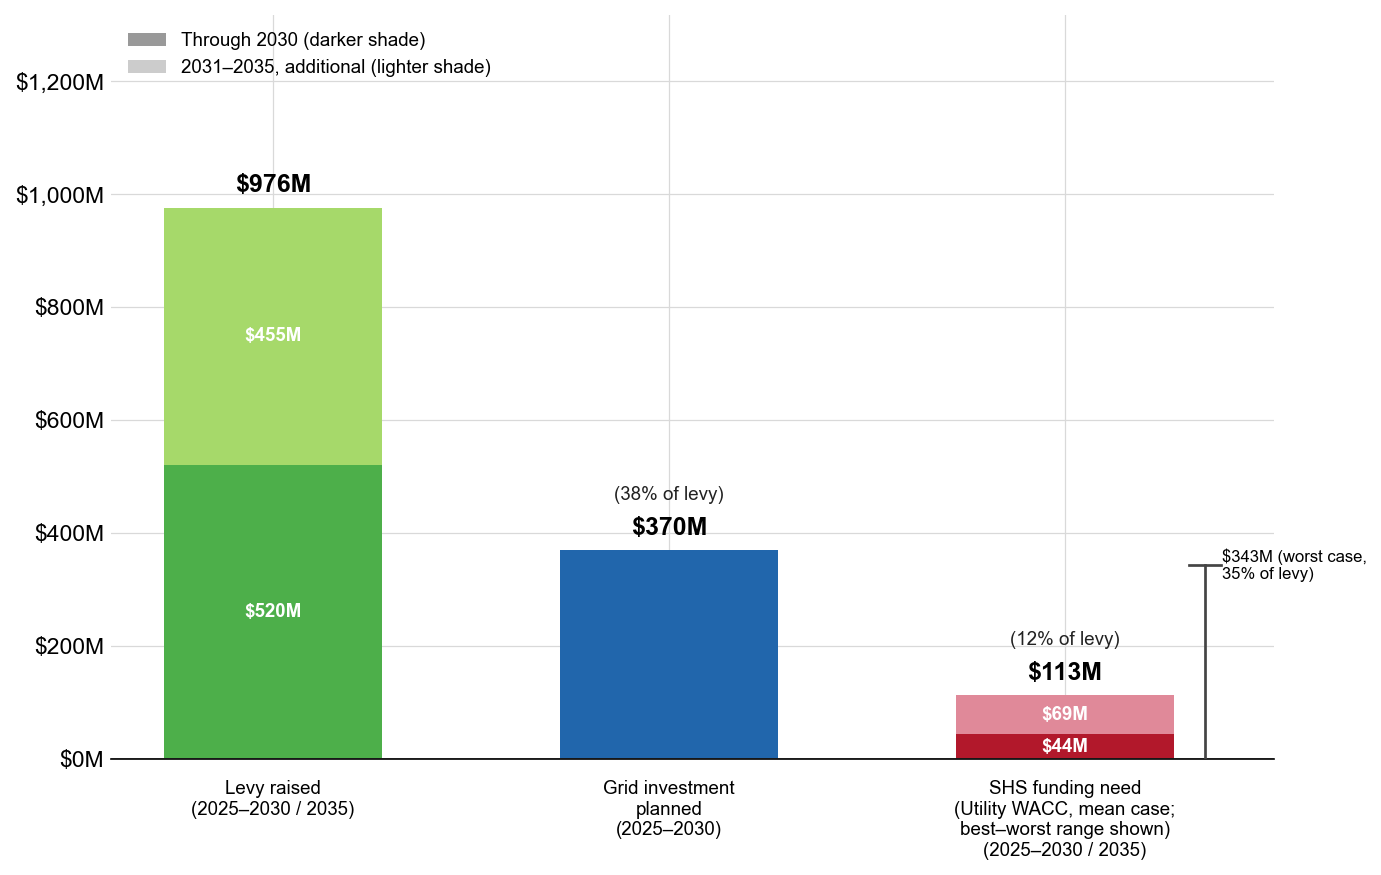

In [ ]:

def fig_kenya_investment_story():
    ws = wb["Model_Kenya_2025"]
    sens = wb["Sensitivity_Analysis"]
    TOTAL_COL = 13

    grid_total     = ws.cell(20, TOTAL_COL).value   # Investment cost Grid
    minigrid_total = ws.cell(21, TOTAL_COL).value   # Investment cost minigrid
    shs_total      = sum(ws.cell(22, c).value or 0 for c in range(2, 13))  # bypass stale hardcoded total cell (M22)
    grand_total    = ws.cell(24, TOTAL_COL).value   # "Total Costs" = Grid + Minigrid + SHS
    assert abs((grid_total + minigrid_total + shs_total) - grand_total) < 1

    levy_2030 = sum(ws.cell(14, c).value for c in range(2, 8))
    levy_2035 = ws.cell(14, TOTAL_COL).value
    levy_extra = levy_2035 - levy_2030

    # Kenya EaaS gap is column E (=5); Utility-WACC rows are 9-14
    utility_rows = list(range(9, 15))
    utility_gaps = [sens.cell(r, 5).value for r in utility_rows]

    min_gap = min(utility_gaps)                          # best case within Utility WACC
    max_gap = max(utility_gaps)                           # worst case within Utility WACC
    central_gap = sum(utility_gaps) / len(utility_gaps)    # mean across the 6 scenarios

    cum_conn = [ws.cell(4, c).value for c in range(2, 13)]  # 2025-2035
    weight_2030 = sum(cum_conn[0:6]) / sum(cum_conn)
    shs_gap_2030 = central_gap * weight_2030
    shs_gap_2031_2035 = central_gap - shs_gap_2030

    COLOR_GRID = "#2166AC"
    COLOR_SHS, COLOR_SHS_LIGHT = "#B2182B", "#E08999"
    COLOR_LEVY, COLOR_LEVY_LIGHT = "#4DAF4A", "#A6D96A"

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.subplots_adjust(top=0.80, bottom=0.18)

    x = [0, 1, 2]
    bar_w = 0.55

    ax.bar(x[0], levy_2030, bar_w, color=COLOR_LEVY)
    ax.bar(x[0], levy_extra, bar_w, bottom=levy_2030, color=COLOR_LEVY_LIGHT)

    ax.bar(x[1], grid_total, bar_w, color=COLOR_GRID)

    ax.bar(x[2], shs_gap_2030, bar_w, color=COLOR_SHS)
    ax.bar(x[2], shs_gap_2031_2035, bar_w, bottom=shs_gap_2030, color=COLOR_SHS_LIGHT)

    bracket_x = x[2] + bar_w / 2 + 0.08
    ax.plot([bracket_x, bracket_x], [min_gap, max_gap], color="#444444", linewidth=1.3, zorder=5)
    for v in (min_gap, max_gap):
        ax.plot([bracket_x - 0.04, bracket_x + 0.04], [v, v], color="#444444", linewidth=1.3, zorder=5)

    pct_grid_only   = grid_total / levy_2035 * 100    # ~38%: grid alone
    pct_mean_case   = central_gap / levy_2035 * 100    # % of levy for mean-case SHS gap
    pct_worst_alone = max_gap / levy_2035 * 100        # ~35%: worst-case SHS gap alone

    ax.annotate(f"${max_gap/1e6:,.0f}M (worst case,\n{pct_worst_alone:.0f}% of levy)", xy=(bracket_x, max_gap),
                xytext=(8, 0), textcoords="offset points", ha="left", va="center", fontsize=8)
    ax.annotate(f"${min_gap/1e6:,.0f}M\n(best case)", xy=(bracket_x, min_gap),
                xytext=(8, 0), textcoords="offset points", ha="left", va="center", fontsize=8)

    ax.annotate(f"${levy_2030/1e6:,.0f}M", xy=(x[0], levy_2030/2), ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax.annotate(f"${levy_extra/1e6:,.0f}M", xy=(x[0], levy_2030 + levy_extra/2), ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")

    if shs_gap_2030 / central_gap > 0.05:
        ax.annotate(f"${shs_gap_2030/1e6:,.0f}M", xy=(x[2], shs_gap_2030/2), ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    if shs_gap_2031_2035 / central_gap > 0.05:
        ax.annotate(f"${shs_gap_2031_2035/1e6:,.0f}M", xy=(x[2], shs_gap_2030 + shs_gap_2031_2035/2),
                    ha="center", va="center", fontsize=9, color="white", fontweight="bold")

    for xi, v in [(x[0], levy_2035), (x[1], grid_total), (x[2], central_gap)]:
        ax.annotate(f"${v/1e6:,.0f}M", xy=(xi, v), xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.annotate(f"({pct_grid_only:.0f}% of levy)", xy=(x[1], grid_total), xytext=(0, 22),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=9, color="#222222")

    ax.annotate(f"({pct_mean_case:.0f}% of levy)", xy=(x[2], central_gap), xytext=(0, 22),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=9, color="#222222")

    top = max(levy_2035, grid_total, max_gap)
    clean_axis(ax, y_money=True)
    ax.set_xticks(x)
    ax.set_xticklabels(["Levy raised\n(2025–2030 / 2035)",
                         "Grid investment\nplanned\n(2025–2030)",
                         "SHS funding need\n(Utility WACC, mean case;\nbest–worst range shown)\n(2025–2030 / 2035)"],
                        fontsize=9)
    ax.tick_params(axis="x", pad=10)
    ax.set_ylim(0, top * 1.35)

    pattern_legend = [Patch(facecolor="#999999", label="Through 2030 (darker shade)"),
                       Patch(facecolor="#CCCCCC", label="2031–2035, additional (lighter shade)")]
    ax.legend(handles=pattern_legend, loc="upper left", frameon=False, fontsize=9)

    save(fig, "figX_kenya_investment_story")
    return fig

fig_kenya_investment_story()
plt.show()
plt.close('all')

Kenya: Avoided Grid = $1,004.1M | SHS gap @10% = $-26.0M | SHS gap @5% = $81.6M
Zambia: Avoided Grid = $1,196.5M | SHS gap @10% = $60.4M | SHS gap @5% = $280.6M
Saved fig_avoided_grid_vs_shs_overlay


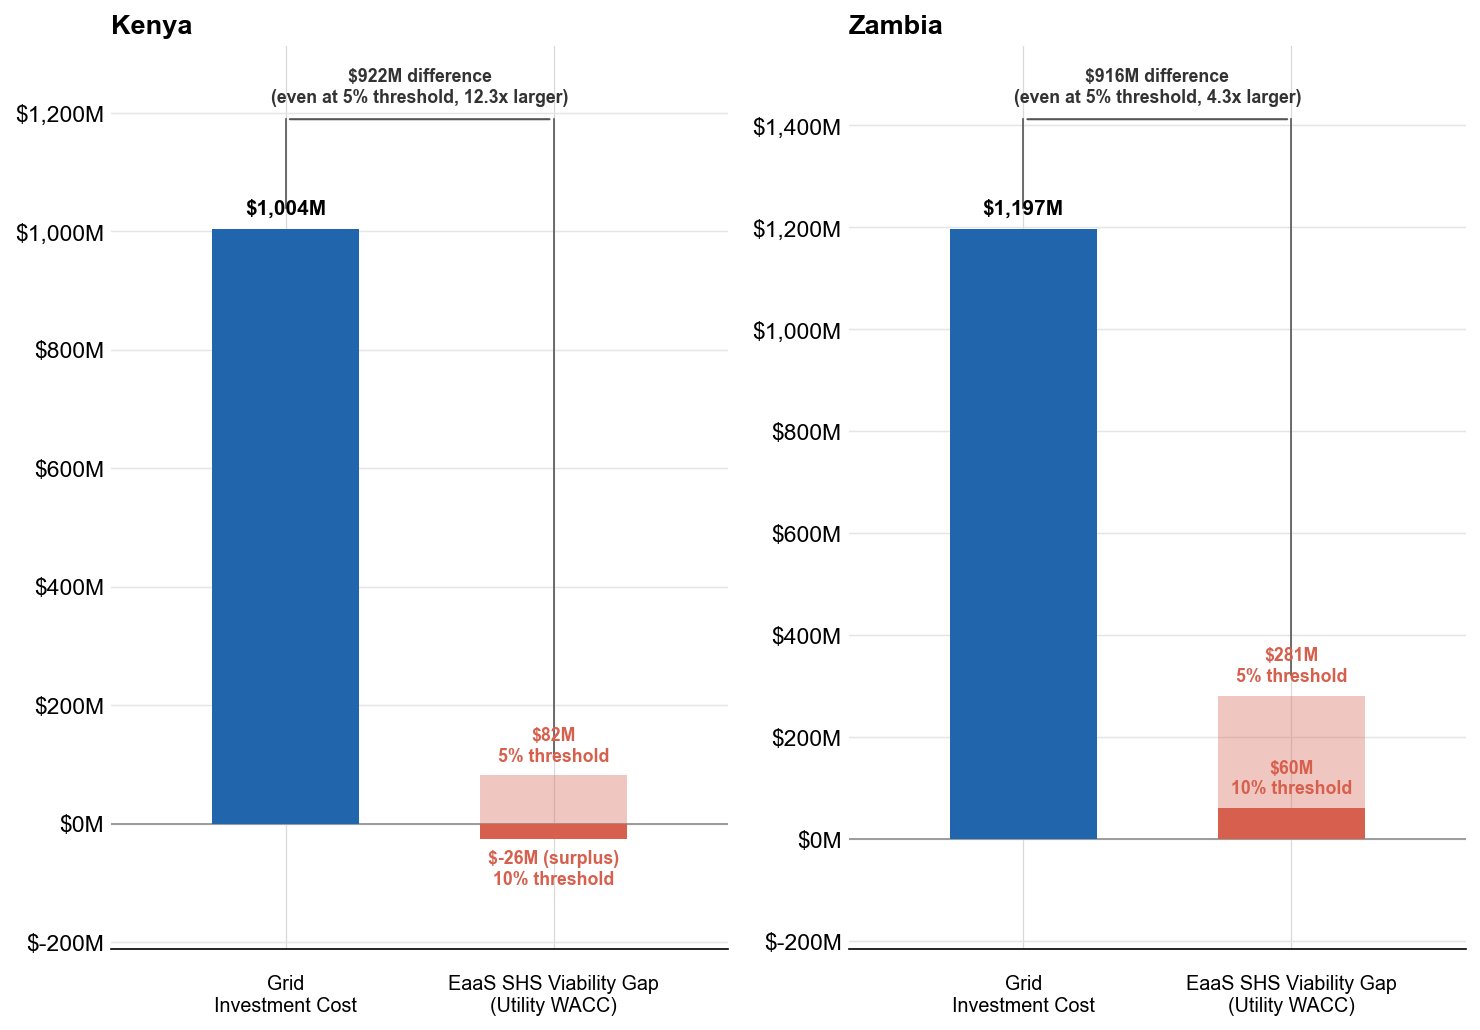

In [ ]:
def fig_avoided_grid_vs_shs_gap():
    ws_sens = wb["Sensitivity_Analysis"]

    ACTIVE_HH_LABEL = "Upper Bound"
    ACTIVE_WACC     = "Utility"

    country_cfg = {
        "Kenya":  {"model_sheet": "Model_Kenya_2025",  "avoided_grid_row": 52,
                   "sens_wacc": 2, "sens_income": 3, "sens_hh": 4, "sens_eaas": 5},
        "Zambia": {"model_sheet": "Model_Zambia_2025", "avoided_grid_row": 53,
                   "sens_wacc": 9, "sens_income": 10, "sens_hh": 11, "sens_eaas": 12},
    }

    def get_eaas_gap(cols, income_label):
        for r in range(3, 15):
            if (ws_sens.cell(r, cols['sens_wacc']).value == ACTIVE_WACC and
                ws_sens.cell(r, cols['sens_income']).value == income_label and
                ws_sens.cell(r, cols['sens_hh']).value == ACTIVE_HH_LABEL):
                return ws_sens.cell(r, cols['sens_eaas']).value
        raise ValueError(f"No row found for Income='{income_label}'")

    results = {}
    for country, cols in country_cfg.items():
        model_ws = wb[cols["model_sheet"]]
        avoided_grid = model_ws.cell(cols["avoided_grid_row"], 13).value
        gap_10pct = get_eaas_gap(cols, "Upper Bound")
        gap_5pct  = get_eaas_gap(cols, "Middle Bound")
        results[country] = {"avoided_grid": avoided_grid, "gap_10pct": gap_10pct, "gap_5pct": gap_5pct}
        print(f"{country}: Avoided Grid = ${avoided_grid/1e6:,.1f}M | "
              f"SHS gap @10% = ${gap_10pct/1e6:,.1f}M | SHS gap @5% = ${gap_5pct/1e6:,.1f}M")

    fig, axes = plt.subplots(1, 2, figsize=(10, 7))  # NOT sharey — each country scales independently
    x_grid, x_shs = 0, 1.0
    bar_width = 0.55

    for ax, country in zip(axes, country_cfg):
        r = results[country]
        grid_val, gap10, gap5 = r["avoided_grid"], r["gap_10pct"], r["gap_5pct"]

        country_vals = [grid_val, gap10, gap5]
        c_ymin, c_ymax = min(0, min(country_vals)), max(country_vals)
        c_yr = c_ymax - c_ymin
        c_pad_bottom = c_yr * 0.18   # proportional to THIS country's own range, not the global one
        ylim = (c_ymin - c_pad_bottom, c_ymax + c_yr * 0.30)

        ax.bar(x_grid, grid_val, color=COLOR_UTILITY, width=bar_width, zorder=3)
        ax.bar(x_shs, gap5, color=COLOR_OPERATOR, alpha=0.35, width=bar_width, zorder=3)
        ax.bar(x_shs, gap10, color=COLOR_OPERATOR, alpha=1.0, width=bar_width, zorder=4)

        ax.annotate(f"${grid_val/1e6:,.0f}M", xy=(x_grid, grid_val), xytext=(0, 5),
                    textcoords="offset points", ha="center", va="bottom", fontsize=10, fontweight="bold")

        va_10 = "top" if gap10 < 0 else "bottom"
        offset_10 = -5 if gap10 < 0 else 5
        label_10 = f"${gap10/1e6:,.0f}M (surplus)" if gap10 < 0 else f"${gap10/1e6:,.0f}M"
        ax.annotate(f"{label_10}\n10% threshold", xy=(x_shs, gap10),
                    xytext=(0, offset_10), textcoords="offset points",
                    ha="center", va=va_10, fontsize=8.5, fontweight="bold", color=COLOR_OPERATOR)

        ax.annotate(f"${gap5/1e6:,.0f}M\n5% threshold", xy=(x_shs, gap5),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=COLOR_OPERATOR)

        bar_top = max(grid_val, gap5, 0)
        bracket_y = bar_top + c_yr * 0.18
        label_clearance = c_yr * 0.035

        ax.annotate('', xy=(x_grid, bracket_y), xytext=(x_shs, bracket_y),
                    arrowprops=dict(arrowstyle='-', color='#555555', lw=1))
        ax.plot([x_grid]*2, [bracket_y, max(grid_val, 0) + label_clearance], color='#555555', lw=0.8)
        ax.plot([x_shs]*2, [bracket_y, max(gap5, 0) + label_clearance], color='#555555', lw=0.8)

        delta = grid_val - gap5
        multiple_str = f"{grid_val / gap5:,.1f}x larger" if gap5 > 0 else "SHS runs at a surplus"
        ax.annotate(f"${delta/1e6:,.0f}M difference\n(even at 5% threshold, {multiple_str})",
                    xy=((x_grid + x_shs)/2, bracket_y), xytext=(0, 6),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold", color="#333333")

        ax.axhline(0, color="#999999", linewidth=0.9, zorder=1)
        ax.set_xticks([x_grid, x_shs])
        ax.set_xticklabels(["Grid\nInvestment Cost", "EaaS SHS Viability Gap\n(Utility WACC)"], fontsize=9.5)
        ax.tick_params(axis='x', pad=12)
        ax.set_ylim(*ylim)
        ax.set_xlim(-0.65, 1.65)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
        ax.set_title(country, fontsize=13, fontweight="bold", loc="left")
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis="both", length=0)
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.7, zorder=0)

    fig.tight_layout()
    save(fig, "fig_avoided_grid_vs_shs_overlay")
    return fig

fig_avoided_grid_vs_shs_gap()
plt.show()
plt.close('all')

Saved fig_paygo_rbf_margin_bars_combined


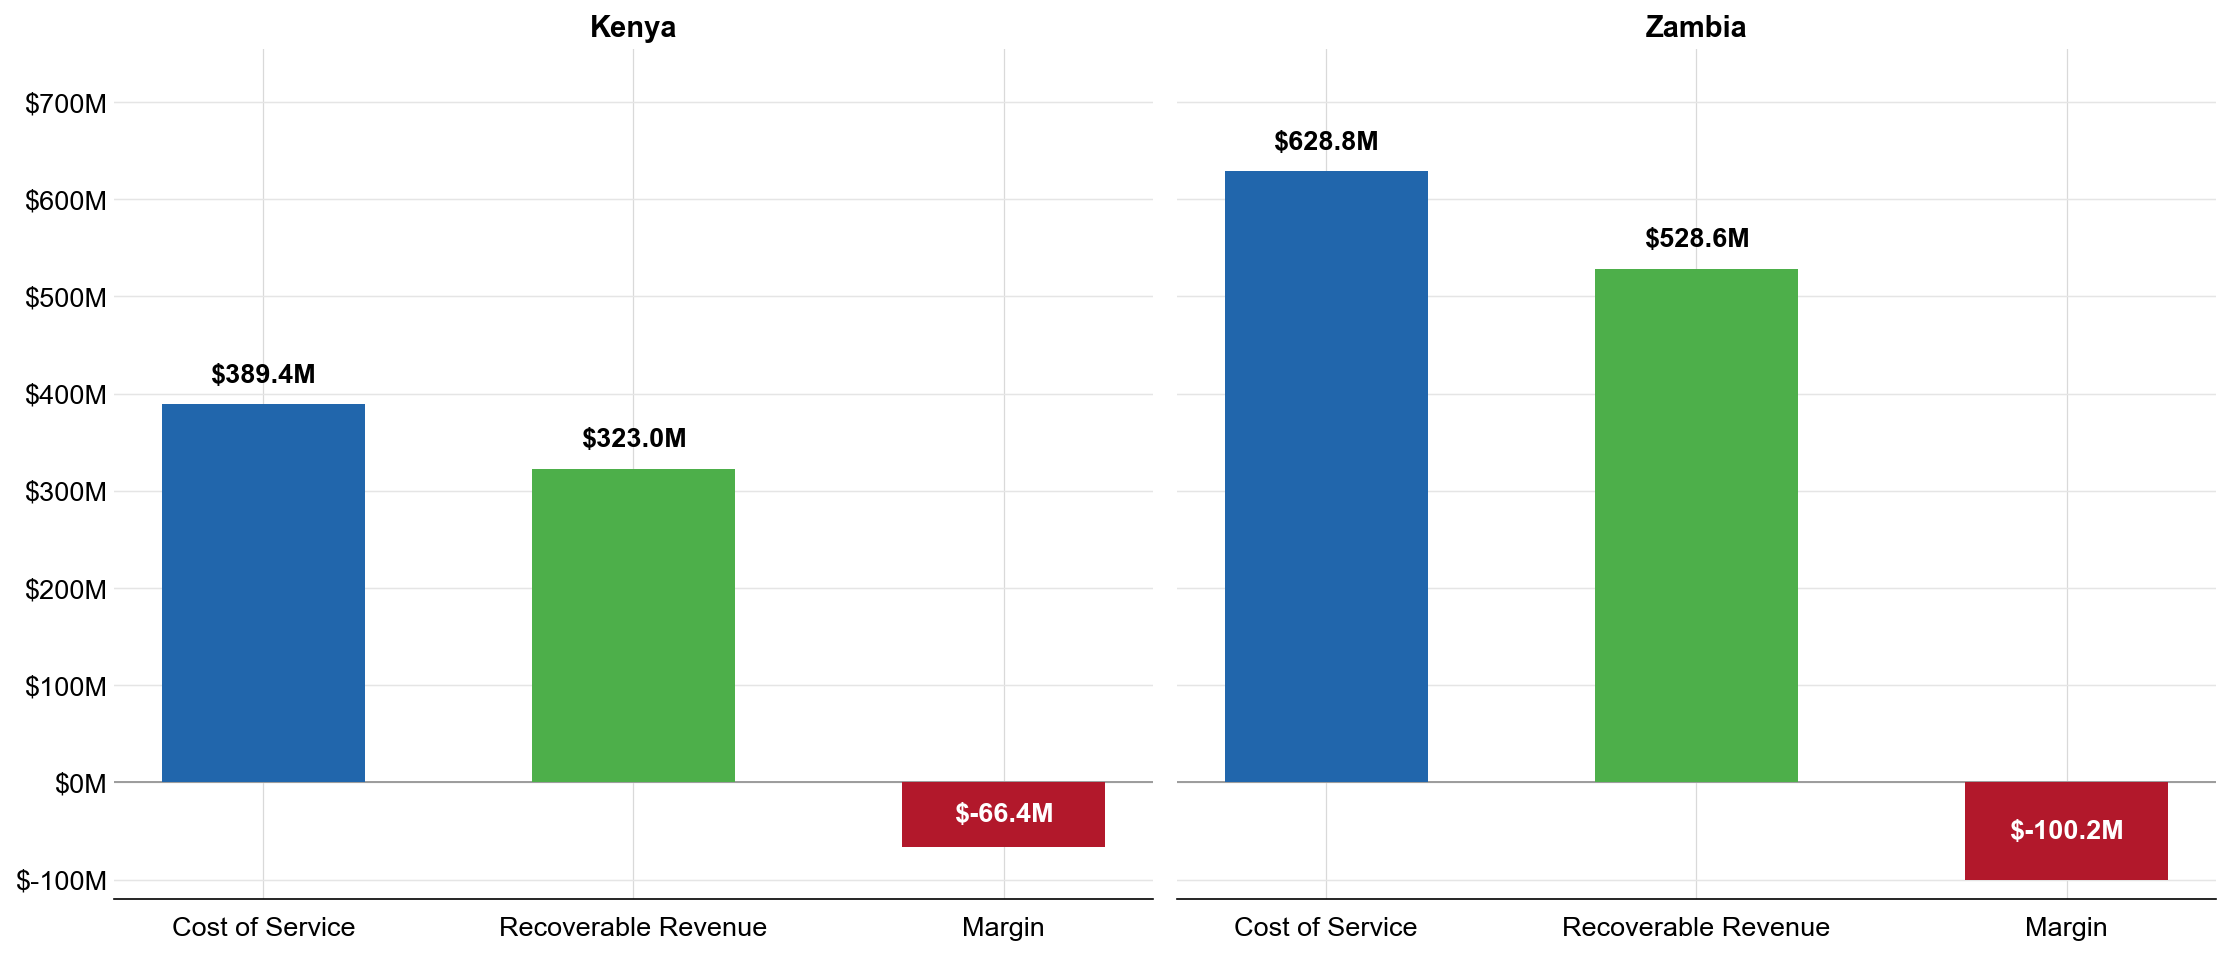

In [ ]:
def fig_paygo_rbf_margin_bars_combined(configs, out_name="fig_paygo_rbf_margin_bars_combined"):
    """
    configs: list of dicts, one per country:
        {"country": "Kenya", "model_sheet": "Model_Kenya_2025",
         "row_cfg": dict(annual_cos=43, market_revenue=49, operator_margin=50)}
    """
    COLOR_COST, COLOR_REV, COLOR_MARGIN = "#2166AC", "#4DAF4A", "#B2182B"
    TOTAL_COL = 13
    labels = ["Cost of Service", "Recoverable Revenue", "Margin"]
    colors = [COLOR_COST, COLOR_REV, COLOR_MARGIN]
    x = [0, 1, 2]

    panel_data = []
    for cfg in configs:
        ws = wb[cfg["model_sheet"]]
        row_cfg = cfg["row_cfg"]

        cost_total    = ws.cell(row_cfg["annual_cos"], TOTAL_COL).value
        revenue_total = ws.cell(row_cfg["market_revenue"], TOTAL_COL).value
        margin_total  = ws.cell(row_cfg["operator_margin"], TOTAL_COL).value

        assert abs(margin_total - (revenue_total - cost_total)) < 1, \
            f"{cfg['country']}: margin doesn't reconcile with cost/revenue — check row_cfg"

        panel_data.append({
            "country": cfg["country"],
            "vals": [cost_total, revenue_total, margin_total],
        })

    all_vals = [v for pd in panel_data for v in pd["vals"]]
    top = max(all_vals) * 1.2
    bottom = min(all_vals) * 1.2 if min(all_vals) < 0 else -top * 0.15

    fig, axes = plt.subplots(1, len(panel_data), figsize=(7.5 * len(panel_data), 6.5), sharey=True)
    if len(panel_data) == 1:
        axes = [axes]

    for ax, pd in zip(axes, panel_data):
        vals = pd["vals"]
        ax.bar(x, vals, color=colors, width=0.55, zorder=3)

        # positive bars: label above, outside the bar
        for xi, v in zip(x[:2], vals[:2]):
            ax.annotate(f"${v/1e6:,.1f}M", xy=(xi, v), xytext=(0, 8),
                         textcoords="offset points", ha="center", va="bottom",
                         fontsize=13, fontweight="bold")

        # margin bar (negative): label centered inside the bar, white text
        margin_total = vals[2]
        ax.annotate(f"${margin_total/1e6:,.1f}M", xy=(x[2], margin_total / 2),
                     ha="center", va="center", fontsize=13, fontweight="bold", color="white")

        ax.axhline(0, color="#999999", linewidth=0.9, zorder=1)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=13)
        ax.tick_params(axis="x", pad=8)
        ax.tick_params(axis="both", length=0, labelsize=13)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.7, zorder=0)
        ax.set_title(pd["country"], fontsize=14, fontweight="bold")

    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
    for ax in axes:
        ax.set_ylim(bottom, top)

    fig.tight_layout()
    save(fig, out_name)
    return fig


fig_paygo_rbf_margin_bars_combined([
    dict(country="Kenya", model_sheet="Model_Kenya_2025",
         row_cfg=dict(annual_cos=43, market_revenue=49, operator_margin=50)),
    dict(country="Zambia", model_sheet="Model_Zambia_2025",
         row_cfg=dict(annual_cos=44, market_revenue=50, operator_margin=51)),
])
plt.show()
plt.close('all')

Saved fig_hh_sensitivity


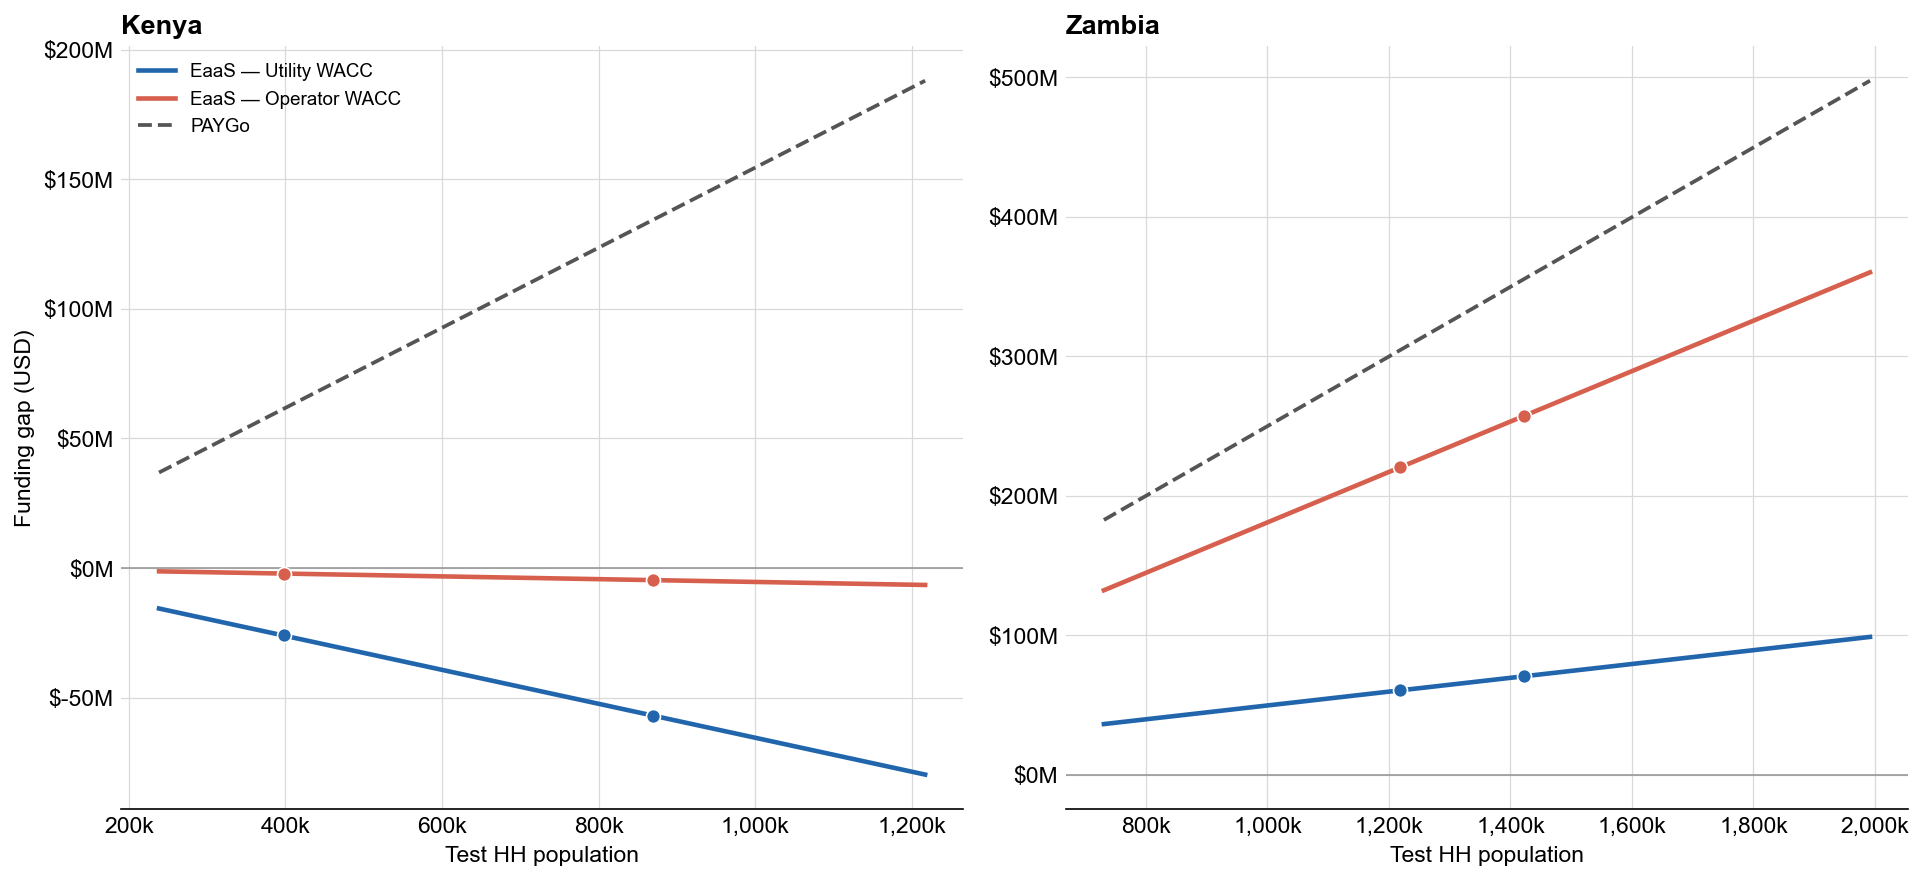

In [ ]:
def _read_sensitivity_sheet(sheet_name):
    """Read Country / WACC scenario / Test value / EaaS gap / PAYGO gap / Marker
    from a sweep sheet, matching on stripped text to avoid hidden-space mismatches."""
    ws = wb[sheet_name]
    rows = []
    r = 3
    while ws.cell(r, 1).value not in (None, ""):
        rows.append({
            "country": str(ws.cell(r, 1).value).strip(),
            "wacc": str(ws.cell(r, 2).value).strip(),
            "x": ws.cell(r, 3).value,
            "eaas": ws.cell(r, 4).value,
            "paygo": ws.cell(r, 5).value,
            "marker": ws.cell(r, 6).value,
        })
        r += 1
    return rows

def fig_hh_sensitivity():
    data = _read_sensitivity_sheet("HH_sensitivity")

    def series(country, wacc):
        pts = sorted([d for d in data if d["country"] == country and d["wacc"] == wacc],
                     key=lambda d: d["x"])
        return pts

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    for ax, country in zip(axes, ["Kenya", "Zambia"]):
        util = series(country, "Utility")
        oper = series(country, "Operator")

        x_util = [d["x"] for d in util]
        x_oper = [d["x"] for d in oper]

        ax.plot(x_util, [d["eaas"] for d in util], color=COLOR_UTILITY, linewidth=2.2,
                label="EaaS — Utility WACC")
        ax.plot(x_oper, [d["eaas"] for d in oper], color=COLOR_OPERATOR, linewidth=2.2,
                label="EaaS — Operator WACC")
        ax.plot(x_util, [d["paygo"] for d in util], color=COLOR_PAYGO, linewidth=1.8,
                linestyle="--", label="PAYGo")

        for pts, color in [(util, COLOR_UTILITY), (oper, COLOR_OPERATOR)]:
            marks = [d for d in pts if d["marker"] == 1]
            ax.scatter([d["x"] for d in marks], [d["eaas"] for d in marks],
                       color=color, zorder=5, s=45, edgecolor="white", linewidth=0.8)

        ax.text(x_util[-1], util[-1]["eaas"], "  EaaS — Operator WACC" if False else "",
                visible=False)  # placeholder, real labels via legend below
        ax.set_title(country, fontsize=13, fontweight="bold", loc="left")
        ax.set_xlabel("Test HH population")
        clean_axis(ax)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e3:,.0f}k"))

    axes[0].set_ylabel("Funding gap (USD)")
    axes[0].legend(loc="upper left", frameon=False, fontsize=9)
    fig.tight_layout()
    save(fig, "fig_hh_sensitivity")
    return fig

fig_hh_sensitivity()
plt.show()
plt.close('all')

Saved fig_income_sensitivity


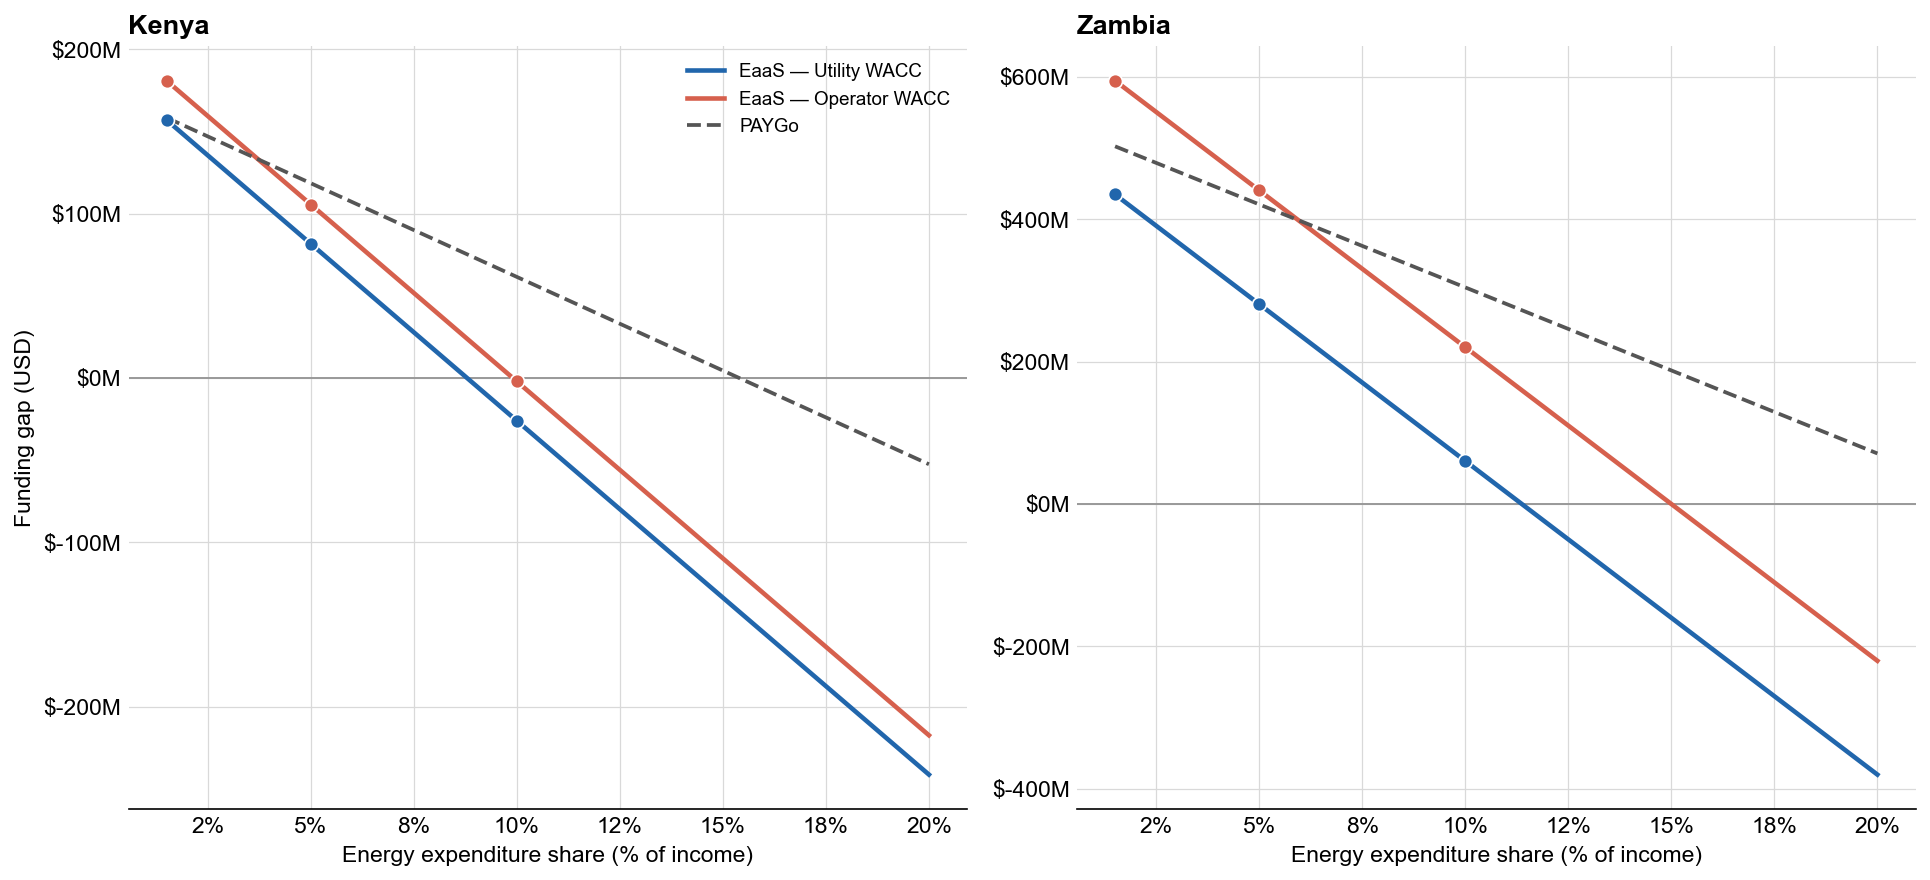

In [ ]:
def fig_income_sensitivity():
    data = _read_sensitivity_sheet("Income_sensitivity")

    def series(country, wacc):
        pts = sorted([d for d in data if d["country"] == country and d["wacc"] == wacc],
                     key=lambda d: d["x"])
        return pts

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    for ax, country in zip(axes, ["Kenya", "Zambia"]):
        util = series(country, "Utility")
        oper = series(country, "Operator")

        x_util = [d["x"] for d in util]
        x_oper = [d["x"] for d in oper]

        ax.plot(x_util, [d["eaas"] for d in util], color=COLOR_UTILITY, linewidth=2.2,
                label="EaaS — Utility WACC")
        ax.plot(x_oper, [d["eaas"] for d in oper], color=COLOR_OPERATOR, linewidth=2.2,
                label="EaaS — Operator WACC")
        ax.plot(x_util, [d["paygo"] for d in util], color=COLOR_PAYGO, linewidth=1.8,
                linestyle="--", label="PAYGo")

        for pts, color in [(util, COLOR_UTILITY), (oper, COLOR_OPERATOR)]:
            marks = [d for d in pts if d["marker"] == 1]
            ax.scatter([d["x"] for d in marks], [d["eaas"] for d in marks],
                       color=color, zorder=5, s=45, edgecolor="white", linewidth=0.8)

        ax.axhline(0, color=COLOR_ZERO, linewidth=0.8, zorder=1)
        ax.set_title(country, fontsize=13, fontweight="bold", loc="left")
        ax.set_xlabel("Energy expenditure share (% of income)")
        clean_axis(ax)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))

    axes[0].set_ylabel("Funding gap (USD)")
    axes[0].legend(loc="upper right", frameon=False, fontsize=9)
    fig.tight_layout()
    save(fig, "fig_income_sensitivity")
    return fig

fig_income_sensitivity()
plt.show()
plt.close('all')